# Final Project for EE546 - Konur Tholl

This is the Jupyter Notebook for Konur Tholl's final project in *EE546 - Introduction to Fuzzy Logic and Neural Networks*

The purpose of this notebook is to implement a fuzzy logic inference engine and various neural models for classifying potential DDoS activity using the CIC-IDS-2017 dataset. This notebook can be organized in three main sections:

- The **Exploratory Data Analysis (EDA)** section is how we reduced the 84 features present in the CIC-IDS-2017 dataset into four features for building our fuzzy inference engine and training our neural models.
- The **Fuzzy Inference Engine** section is how we implemented, designed, and evaluated the Mamdani-type fuzzy logic inference engine for classifying DDoS activity using the four features found from EDA.
- The **Neural Models** section covers building, training, and evaluating various neural models using the same four features. These models include, a single perceptron, an Adaptive Linear Neuron (ADALINE) network, and a Multi-Layer Perceptron (MLP).

Using F1-Score as the primary metric of success, we can see that performance from best to worst is:
- MLP: 99.91%
- Perceptron: 96.23%
- Fuzzy Inference Engine: 91.19%
- ADALINE: 78.29%


*Please note that this notebook is designed to be run sequentially (from top to bottom). Running cells without executing the previous ones will lead to errors and/or unexpected behavior. The entire notebook takes ~7 minutes to run*

## 1. Exploratory Data Analysis
Ref EDA youtube tutorial using pandas: https://www.youtube.com/watch?v=Liv6eeb1VfE

For the Fuzzy system, we need to have a good understanding of which features are good for differentiating between malicious and benign samples.


### 1.1 High-Level Analysis and Pruning
We start off by getting high-level details of the CIC-IDS-2017 DDoS dataset. We can see the dataset is quite large with a total of 225,745 samples, each having 84 features with 128,027 malicious (DDoS) and 97,718 benign.

Doing a quick analysis of the dataset, values appear to make sense. For example, IP addresses appear to always be in valid IPv4 format, flow durations are positive values, etc. It can be seen that the majority of the traffic contained within this dataset is web-based (port 443 or 80); however, other protocols like SSH and NTP (assuming they are using standard ports) exist.

Overall, this dataset aligns with expectations, and should be an operational fit for evaluating the feasibility of using fuzzy logic controllers and neural models for intrusion detection!

In [236]:
#Doing initial high-level analysis on our dataset 

import pandas as pd
#Tried various dataset that CIC-IDS-2017 had available - DDoS shows the most promise!
datasetPath='data/DDoSDataset_546.csv'
#datasetPath='data/PortscanDataset_546.csv'
#datasetPath='data/WebAttackDataset_546.csv'
#datasetPath='data/InfiltrationDataset_546.csv'

#Some of the datasets tried had different encodings
try:
    df=pd.read_csv(datasetPath)
except:
    df=pd.read_csv(datasetPath,encoding='cp1252')
#Strip all trailing and leading white space in column names
df.columns = df.columns.str.strip()

#Drop any duplicates found in df (was leaking testing data into training in further analysis)
df=df.drop_duplicates()

print("----------Printing high-level information for the dataset------------")
print("Unique Labels:")
print(df["Label"].value_counts())
print("Unique Ports:")
print(f"Total Samples: {df.shape[0]}")
print(f"Total Features: {df.shape[1]-1}")

----------Printing high-level information for the dataset------------
Unique Labels:
Label
DDoS      128027
BENIGN     97716
Name: count, dtype: int64
Unique Ports:
Total Samples: 225743
Total Features: 84


In [237]:
#Printing information on the dataset - all is as expected (no surprises!)
df.info()

<class 'pandas.DataFrame'>
Index: 225743 entries, 0 to 225744
Data columns (total 85 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Flow ID                      225743 non-null  str    
 1   Source IP                    225743 non-null  str    
 2   Source Port                  225743 non-null  int64  
 3   Destination IP               225743 non-null  str    
 4   Destination Port             225743 non-null  int64  
 5   Protocol                     225743 non-null  int64  
 6   Timestamp                    225743 non-null  str    
 7   Flow Duration                225743 non-null  int64  
 8   Total Fwd Packets            225743 non-null  int64  
 9   Total Backward Packets       225743 non-null  int64  
 10  Total Length of Fwd Packets  225743 non-null  int64  
 11  Total Length of Bwd Packets  225743 non-null  int64  
 12  Fwd Packet Length Max        225743 non-null  int64  
 13  Fwd Packet Leng

In [238]:
#Printing expected values of features - can see that they make sense (e.g., no negative value for Packet Lengths)
df.describe()

c:\Users\konur\miniconda3\envs\546FinalProject\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\konur\miniconda3\envs\546FinalProject\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,225743.000000,225743.000000,225743.000000,2.257430e+05,225743.000000,225743.000000,225743.000000,2.257430e+05,225743.000000,225743.000000,...,225743.000000,225743.000000,2.257430e+05,2.257430e+05,2.257430e+05,2.257430e+05,2.257430e+05,2.257430e+05,2.257430e+05,2.257430e+05
mean,38257.432270,8879.575717,7.600302,1.624179e+07,4.874942,4.572815,939.471669,5.960530e+03,538.540464,27.882468,...,3.311527,21.482659,1.848277e+05,1.293447e+04,2.080867e+05,1.776217e+05,1.032223e+07,3.611975e+06,1.287824e+07,7.755424e+06
std,23057.358855,19754.718263,3.881601,3.152448e+07,15.422939,21.755448,3249.416675,3.921851e+04,1864.136559,163.324861,...,12.270068,4.166700,7.979284e+05,2.102746e+05,9.002388e+05,7.842635e+05,2.185310e+07,1.275695e+07,2.692136e+07,1.983117e+07
min,0.000000,0.000000,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,18989.500000,80.000000,6.000000,7.118200e+04,2.000000,1.000000,26.000000,0.000000e+00,6.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,49799.000000,80.000000,6.000000,1.452338e+06,3.000000,4.000000,30.000000,1.640000e+02,20.000000,0.000000,...,2.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,58296.000000,80.000000,6.000000,8.805241e+06,5.000000,5.000000,63.000000,1.160100e+04,34.000000,6.000000,...,4.000000,20.000000,1.878000e+03,0.000000e+00,1.878000e+03,1.862000e+03,8.239740e+06,0.000000e+00,8.253854e+06,7.422860e+06
max,65534.000000,65532.000000,17.000000,1.199999e+08,1932.000000,2942.000000,183012.000000,5.172346e+06,11680.000000,1472.000000,...,1931.000000,52.000000,1.000000e+08,3.950000e+07,1.000000e+08,1.000000e+08,1.200000e+08,6.530000e+07,1.200000e+08,1.200000e+08


From the below, we can see that there are non-numerical features in this dataset which include: 'Flow ID', ' Source IP', ' Destination IP', ' Timestamp'. Ideally, we would explore some of these features in detail and try to derive meaningful information from them to generate new features (e.g., internal vs external IP); however, for the sake of simplicity we'll just remove them and keep the numerical ones for this project! 

We also chose to drop the source port and destination port. This is because it was discovered in later training that the model was relying heavily on the destination port for distinguishing between malicious and benign traffic. Relying on ports for detecting DDoS attempts is unrealstic in real cybersecurity operations as the attacker can easily change the used ports and be just as effective in their DDoS effect. As such, the source and destination ports were removed from this dataset.

In [239]:
#Printing the non-numeric features - can see these are logical (IP addresses, label names, etc)

nonNumeric=df.select_dtypes(exclude=["number"])
print(f"Non numeric features: {nonNumeric.columns}")

#Drop the non-numeric features (except for the label of course!)
df=df.drop(columns=[feat for feat in nonNumeric.columns if feat!= "Label"])

#Also drop the source and destination port for the reasons discussed above!
df=df.drop(columns=["Source Port", "Destination Port"])

Non numeric features: Index(['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'Label'], dtype='str')


Seeing if there are any NaN or infinityvalues present in the dataset - can see that there are 4 NaN values for Flow Bytes/s.
Just going to replace these with 0!


In [240]:
#Checking if there are any invalid or infinity numbers present to deal with promptly!

import numpy as np
#Print number of NaN values for each feature
print("Checking NaN values for each feature:")
NaNCounts=df.isnull().sum()
print(NaNCounts[NaNCounts>0])
#Replace the previously identified NaNs in the Flow Bytes/s column with 0s
df["Flow Bytes/s"] = df["Flow Bytes/s"].fillna(0)

#Print number of infinity values for each feature
print("Checking infinity values for each feature:")
x=df.drop(columns=["Label"])
print(np.isinf(x).sum()[np.isinf(x).sum() > 0])
#Replace previously identified infinity values in the Flow Bytes/s and Flow Packets/s with 0s!
df[["Flow Bytes/s", "Flow Packets/s"]]=df[["Flow Bytes/s", "Flow Packets/s"]].replace([np.inf, -np.inf], 0)

Checking NaN values for each feature:
Flow Bytes/s    4
dtype: int64
Checking infinity values for each feature:
Flow Bytes/s      30
Flow Packets/s    34
dtype: int64


Now, we're checking to see if there are any features with zero variation. If there is zero variation, then they are essentially useless for classifying samples as they have the same value for all possible classes - in otherwords, they have no use for our fuzzy system and we can simply drop them!

We can see that the following features have zero variance across the dataset and thus were dropped: Bwd PSH Flags, Fwd URG Flags, Bwd URG Flags, CWE Flag Count, Fwd Avg Bytes/Bulk, Fwd Avg Packets/Bulk, Fwd Avg Bulk Rate, Bwd Avg Bytes/Bulk, Bwd Avg Packets/Bulk, Bwd Avg Bulk Rate.

After dropping these, we now have 70 features in our dataset (not including the label).

In [241]:
#Getting all features that have zero variation (are the same throughout entire set making them useless for classification)

#Get the number of unique values per feature
numUnique=df.nunique()

#Print features that have one or less unique value (meaning zero variance = no contribution to classifying!)
print("Columns that have zero variance (same value across all samples):")
print(numUnique[numUnique<=1])

#Because these values have zero contribution to classifying, we don't care about them when implementing our fuzzy system, so can just drop them!
df=df.drop(columns=df.columns[df.nunique()<=1])

#Print new number of columns after dropping
print(f"New number of features: {len(df.columns)-1}")

Columns that have zero variance (same value across all samples):
Bwd PSH Flags           1
Fwd URG Flags           1
Bwd URG Flags           1
CWE Flag Count          1
Fwd Avg Bytes/Bulk      1
Fwd Avg Packets/Bulk    1
Fwd Avg Bulk Rate       1
Bwd Avg Bytes/Bulk      1
Bwd Avg Packets/Bulk    1
Bwd Avg Bulk Rate       1
dtype: int64
New number of features: 68


### 1.2 Correlation Analysis

Now, we're creating a correlation heat map to see how dependent features are on eachother. This is important for fuzzy systems to avoid any unneeded redundancy overhead in how we implement our rules. For example if features A and B are completely correlated, then using just one of our features in our rules will be just as efficient as using both (perhaps more effective to avoid over committing to certain classes).

                             Protocol  Flow Duration  Total Fwd Packets  \
Protocol                     1.000000      -0.194693          -0.077461   
Flow Duration               -0.194693       1.000000           0.207660   
Total Fwd Packets           -0.077461       0.207660           1.000000   
Total Backward Packets      -0.052777       0.145272           0.956714   
Total Length of Fwd Packets -0.107640       0.297831           0.174396   
...                               ...            ...                ...   
Active Min                  -0.092238       0.413834           0.087691   
Idle Mean                   -0.169638       0.871855           0.110786   
Idle Std                    -0.116059       0.630603           0.056807   
Idle Max                    -0.176679       0.919199           0.109428   
Idle Min                    -0.133860       0.672002           0.094746   

                             Total Backward Packets  \
Protocol                                  -0

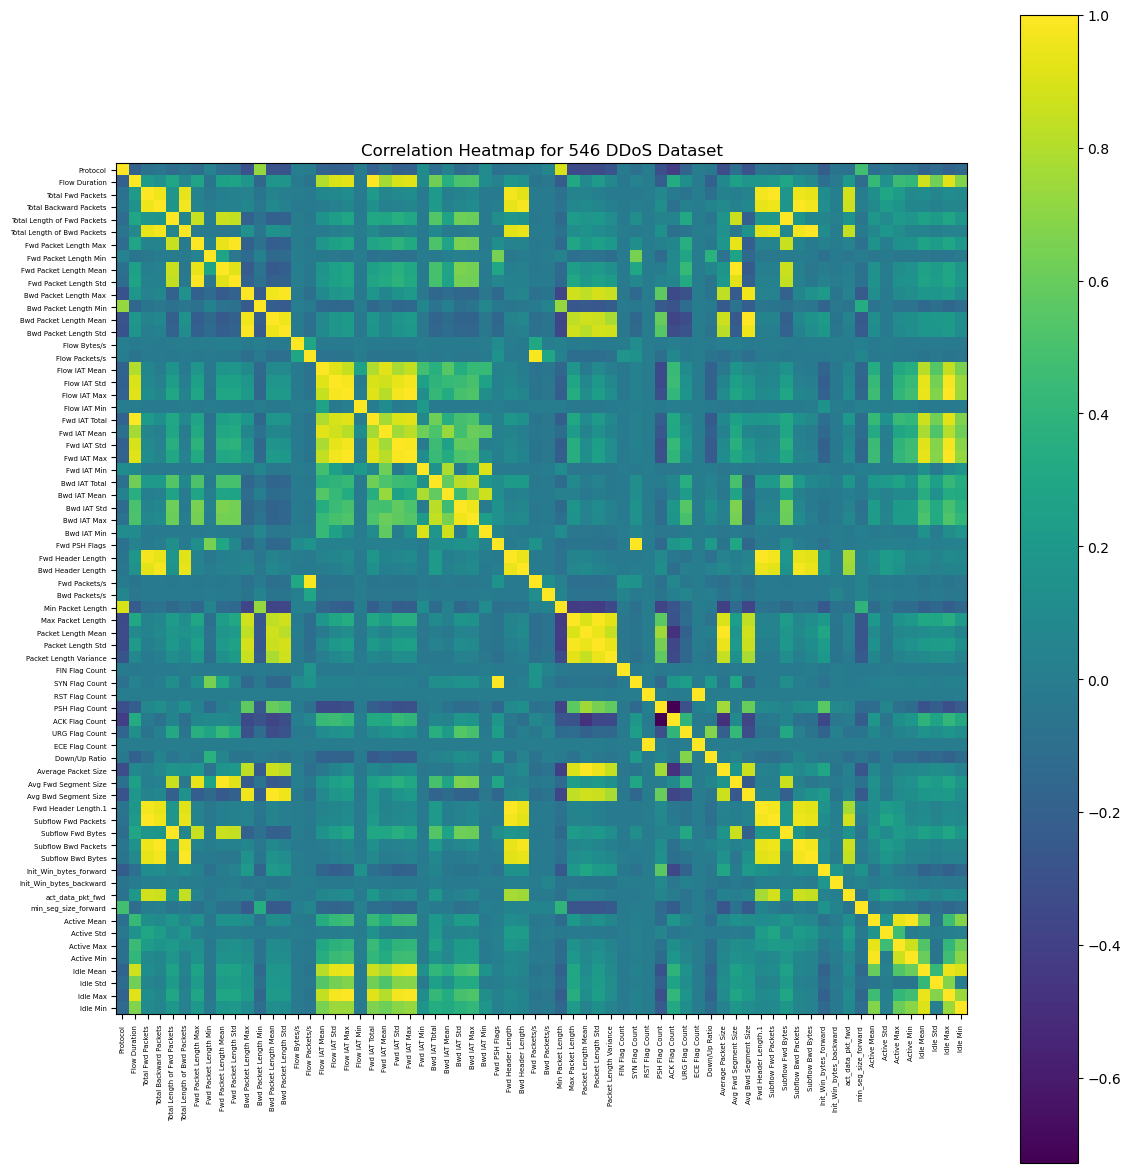

Total Fwd Packets            Subflow Fwd Packets     1.000000
Total Backward Packets       Subflow Bwd Packets     1.000000
Total Length of Fwd Packets  Subflow Fwd Bytes       1.000000
Fwd Packet Length Mean       Avg Fwd Segment Size    1.000000
RST Flag Count               ECE Flag Count          1.000000
                                                       ...   
Fwd IAT Std                  Idle Mean               0.913070
Idle Mean                    Idle Min                0.910822
Fwd IAT Min                  Bwd IAT Min             0.906124
Max Packet Length            Packet Length Mean      0.904039
                             Average Packet Size     0.900051
Length: 89, dtype: float64
Number of feature pairs >= 0.9: 89
Total Fwd Packets - Subflow Fwd Packets: 100.000%
Total Backward Packets - Subflow Bwd Packets: 100.000%
Total Length of Fwd Packets - Subflow Fwd Bytes: 100.000%
Fwd Packet Length Mean - Avg Fwd Segment Size: 100.000%
RST Flag Count - ECE Flag Count: 100.

In [242]:
#Using pandas built-in function to get how correlated features are to eachother and plotting this on a heat map

import matplotlib.pyplot as plt
import numpy as np

#Convert textual labels to integer values (1 for malicious, 0 for benign)
df["Label"]=df["Label"].apply(lambda x: 1 if x=="DDoS" else 0)

#Create another dataframe without label column for feature investigation
x=df.drop(columns=["Label"])

#Using builtin pandas functionality to create correlation between features - is just column*column matrix where each cell represents how correlated the 2 features are
corrMatrix=x.corr(numeric_only=True)
print(corrMatrix)

#Ensuring figures are big enough
plt.figure(figsize=(12,12))

#Plot the matrix of numbers as colored image and show the corresponding legend
plt.imshow(corrMatrix)
plt.colorbar()

#Plot the axis names (the column names) - rotate x 90 degrees so readable
plt.xticks(range(len(corrMatrix.columns)), corrMatrix.columns, rotation=90, fontsize=5)
plt.yticks(range(len(corrMatrix.columns)), corrMatrix.columns, fontsize=5)

#Add title to plot and show it!
plt.title("Correlation Heatmap for 546 DDoS Dataset")
plt.tight_layout()
plt.show()

#Get all features with a correlation higher than 90%! 
#Asked ChatGPT if there was more efficient way than looping like below, and there is! It used np.triu method to mask any duplicates
corrMatrix = x.corr(numeric_only=True).abs()
mask=np.triu(np.ones(corrMatrix.shape),k=1).astype(bool)
#Remove any duplicates and diagonals
upper=corrMatrix.where(mask)
pairs=upper.stack()
pairs=pairs[pairs>=0.9].sort_values(ascending=False)
print(pairs)
print(f"Number of feature pairs >= 0.9: {len(pairs)}")
for (feat1, feat2), value in pairs.items():
    print(f"{feat1} - {feat2}: {value*100:.3f}%")

#Original less efficient way of doing the above
# print("Features with correlation higher or equal to 90%:")
# for feat1 in corrMatrix.columns:
#     for feat2 in corrMatrix.columns:
#         #Doing this to avoid duplicates!
#         if feat1 < feat2:
#             if abs(corrMatrix.loc[feat1,feat2]) >= 0.9:
#                 print(f"Features {feat1} and {feat2} have a correlation of {corrMatrix.loc[feat1,feat2]*100:.3f}%")


From the above correlation analysis, we can see that there 89 pairs of features with a correlation value higher or equal to 90%.

Now, we're dropping the first of the features. Note that because upper is directional (ref ChatGPT for helping get the direction mask working using df.triu), we can simply remove where the feature has a correlation greater or equal to 0.9 without removing the entire pair.

After applying this greedy correlation drop, we can see we're now down to 33 features!

In [243]:
#Dropping features where correlation is greater than or equal to 0.9 (90%)

featuresToDrop=[feat for feat in upper.columns if any(upper[feat]>=0.9)]
print(f"Dropping {len(featuresToDrop)} features due to high correlation")
#Just putting in try in case running this after completing the drop (to avoid having to rerun cells)
try:
    df=df.drop(columns=featuresToDrop)
except:
    pass
#Re-initialize x (dataset without label column) with the refined features
x=df.drop(columns=["Label"])
print(f"New number of features: {len(x.columns)}")

Dropping 35 features due to high correlation
New number of features: 33


### 1.3 Random Forest Analysis
Now we're using the Random Forest (RF) algorithm to determine which features are the most important WRT distinguishing between the DDoS and benign classes.
What we're doing is using an RF to split the samples into various classes based on individual feature thresholds and keep track of the impurity reduction attributed by each split.
For example, if feature A < 0.8 was able to split all samples into 2 distinct classes, the purity score of Feature A would be very high.
The purity scores of each feature are then summed across decision trees and normalized to get a score of how each feature is able to distinguish between the two classes.

From the analysis below, we chose 10 features of interest based on their ability to split samples (using their impurity reduction scores and similarities to other features). We chose features across five families: Forward packet size, behavior, backward size, timing and bandwidth.
- Forward size: Total Length of Fwd Packets, Fwd Packet Length Max, Total Fwd Packets, act_data_pkt_fwd
- Behavior: Init_Win_bytes_forward
- Backward size: Bwd Packet Length Min, Bwd Packet Length Max
- Timing: Flow Duration, Bwd IAT Mean
- Bandwidth: Flow Packets/s, Flow Bytes/s

In [244]:
#Using the RF algorithm to estimate feature importance

from sklearn.ensemble import RandomForestClassifier

#Doing -1 to use all cores as was observed to be slow
rf=RandomForestClassifier(n_estimators=100, random_state=20, n_jobs=-1)

rf.fit(x,df["Label"])

#Compute the importance of the features using the algorithm described above (ref: https://scikit-learn.org/stable/auto_examples)
featureImportances=pd.Series(rf.feature_importances_, index=x.columns)
featureImportances.sort_values(ascending=False)

Total Length of Fwd Packets    0.150273
Fwd Packet Length Max          0.120475
Init_Win_bytes_forward         0.108988
Total Fwd Packets              0.105127
act_data_pkt_fwd               0.102220
Bwd Packet Length Min          0.078729
Bwd Packet Length Max          0.059360
Init_Win_bytes_backward        0.042719
Fwd Packet Length Min          0.031528
Max Packet Length              0.024405
Bwd IAT Mean                   0.022089
Bwd IAT Std                    0.020257
Flow Duration                  0.019365
URG Flag Count                 0.014708
Min Packet Length              0.013842
min_seg_size_forward           0.012365
Bwd IAT Total                  0.011723
Protocol                       0.011605
Down/Up Ratio                  0.009349
Bwd Packets/s                  0.008665
Flow IAT Mean                  0.008452
Flow Packets/s                 0.007940
Fwd IAT Min                    0.005576
Flow Bytes/s                   0.003309
Flow IAT Min                   0.002020


Keeping the features of interest identified from the impurity analysis above

In [245]:
#Only keep features of interest from the above analysis

featuresOfInterest=["Total Length of Fwd Packets", "Fwd Packet Length Max", "Total Fwd Packets", "act_data_pkt_fwd", "Init_Win_bytes_forward", "Bwd Packet Length Min", "Bwd Packet Length Max", "Flow Duration", "Bwd IAT Mean", "Flow Packets/s", "Flow Bytes/s","Label"]
df=df[featuresOfInterest]

### 1.4 Box Plot Analysis
Ref what Mr. Brian Lachine taught us in EE593

Now, we're doing a box plot analysis to determine the distribution across the malicious and benign samples for each feature to see if there are any that show promise for distinguishing between the two classes.

Analysis of the box plots:
##### Forward Family of Features
**Total Length of Fwd Packets**
	- Using this feature, we can see that the Q1-Q3 spread of benign samples is ~10-1,000 versus ~21-23 for the malicious samples. Furthermore, we can see there is not a single malicious sample with a Forward Packet Total Length that is higher than ~100. This makes it a great feature for differentiating between malicious and benign samples.
	
**Fwd Packet Length Max**
	- This feature shows that the Q1-Q3 distribution for benign is ~5-550 and ~5-25 for malicious. This means we can set a threshold of ~25 to classify many of the samples.
	
**Total Fwd Packets**
	- For this feature, we can see that the range (excluding outliers) is roughly the same for malicious and benign samples (~1-10 for benign and ~1-8 for malicious). With them being centered around 2 and 4, respectively, there is a lot of overlap between the majority of the samples, making it hard to define a threshold for classifying. We can see that there are benign outliers that are range from ~10-1,000 with no malicious outliers exceeding 10. This feature is not as strong as the previous two; however, can catch some of the benign outliers with certainty.
	
**act_data_pkit_fwd**
	- The Q1-Q3 range for benign is ~0-3 for benign and ~2-4 for malicious. We can use a threshold in these ranges to differentiate between the two; however, there will be some overlap. Similar to to the above, there are benign outliers that extend past 1,000, with the highest mlicious outlier being 10. 
	
##### Backward Family of Features
**Bwd Packet Length Min (Backward Family)**
	- The vast majority of malicious samples (127,729 out of 128,027) are 0 which is why no Q1-Q3 box is shown. We can use this to say that any sample with a Bwd Packet Length in between 5 and 1,000 is benign with certainty; however we would only catch roughly 350 samples.
	
**Bwd Packet Length Max**
	- We can see that the Q1-Q3 ranges for this feature are greatly different between malicious and benign with ~5-100 for benign and ~0-7,000 for malicious with the malicious median being ~6,000 and the benign median being ~20. We can set a threshold of higher than 300 and say with high probability (not certainty) that the sample is malicious.

##### Behaviour Family of Features
**Init_Win_bytes_forward**
	- Benign shows a Q1-Q3 range of ~200-1,000 with a median centered ~220 whereas malicious shows Q1-Q3 of ~250-9,000. This is not as strong as the previous feature, but we could set a threshold of 5,000 and say with high probability that it's malicious.
	
##### Timing Family of Features
**Flow Duration**
	- Benign has Q1-Q3 of ~300-8,000,000 with Malicious showing Q1-Q3 of ~600,000-10,000,000. Using this feature, we can say with a decently high probability that anything under ~550,000 is malicious 

**Bwd IAT Mean**
	- Benign has a Q1-Q3 of ~0-1,000,000 with malicious showing ~0-200,000. Benign is centerd around ~30 with malicious being centered around ~20,000. Additionally, we see that there are no malicious samples with a feature value greater than 2,000,000.

##### Bandwidth Family of Features
**Flow Packets/s**
	- Benign has a Q1-Q3 distribution of ~1-10,000 whereas Malicious has ~1-20. Overlap between malicious and benign, but can say vast majority will be benign setting a Flow Packet/s threshold of above 11

**Flow Bytes/s**
	- Malicious has a Q1-Q3 of ~7-20,000 while benign has Q1-Q3 of ~80-100,000. With the benign samples being centered over ~2,000 and malicious being centered over ~200, we can set a threshold classifying anything lower than 100 has malicious; however, there will be considerate overlap with benign samples.
	

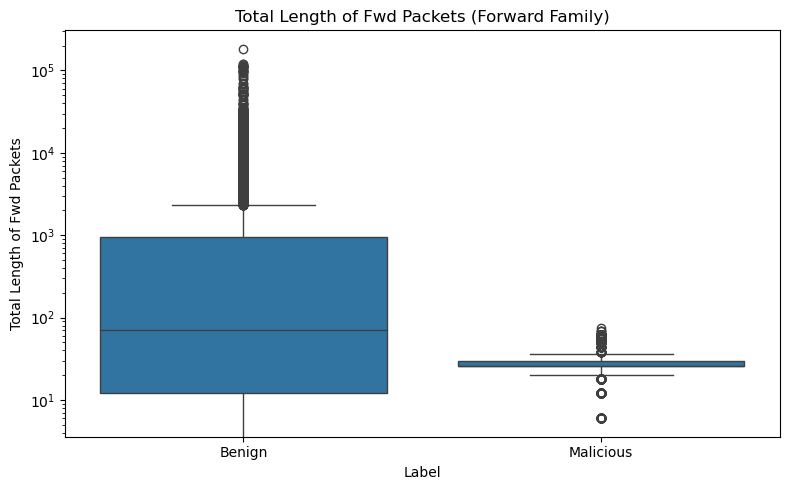

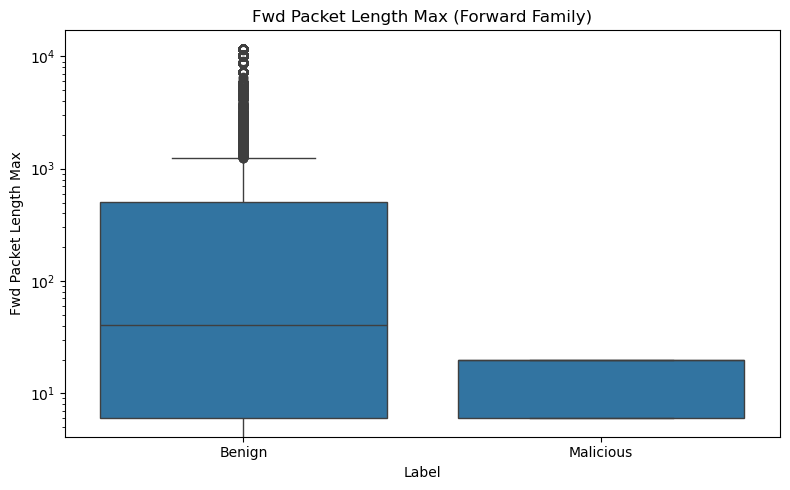

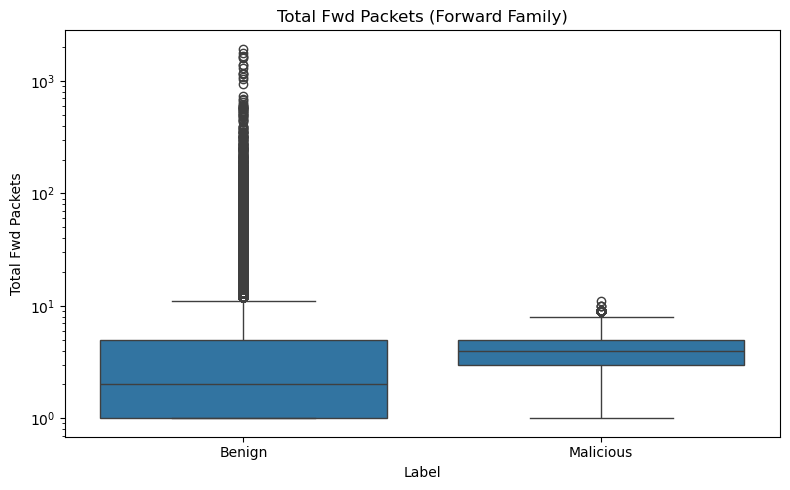

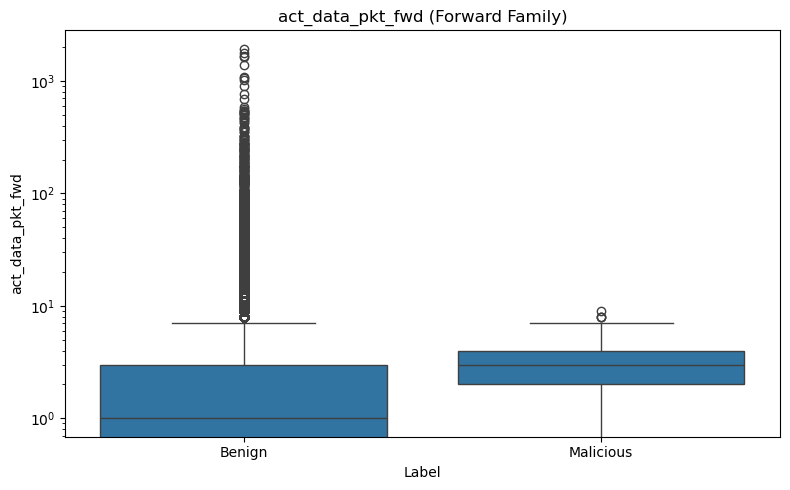

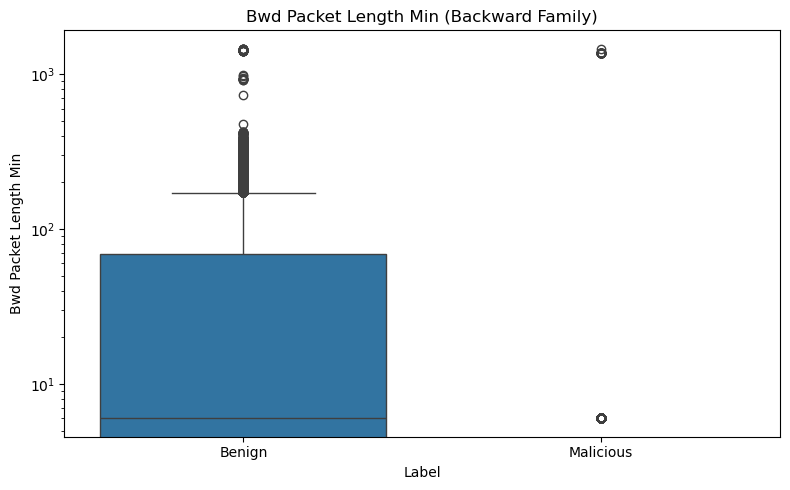

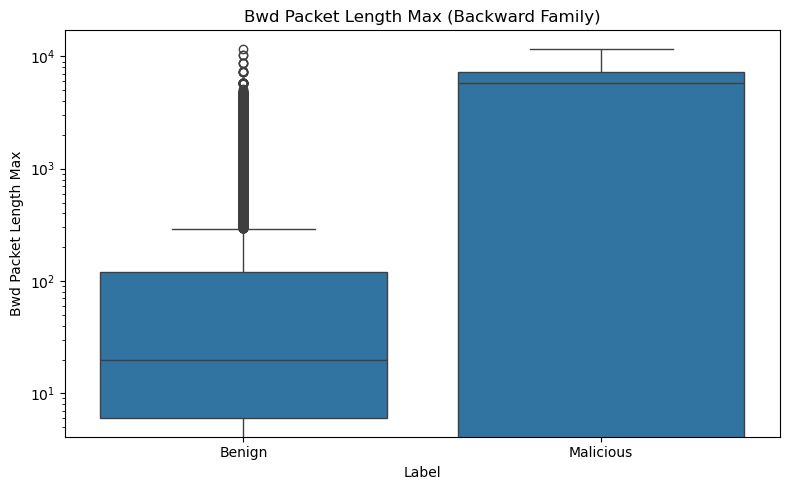

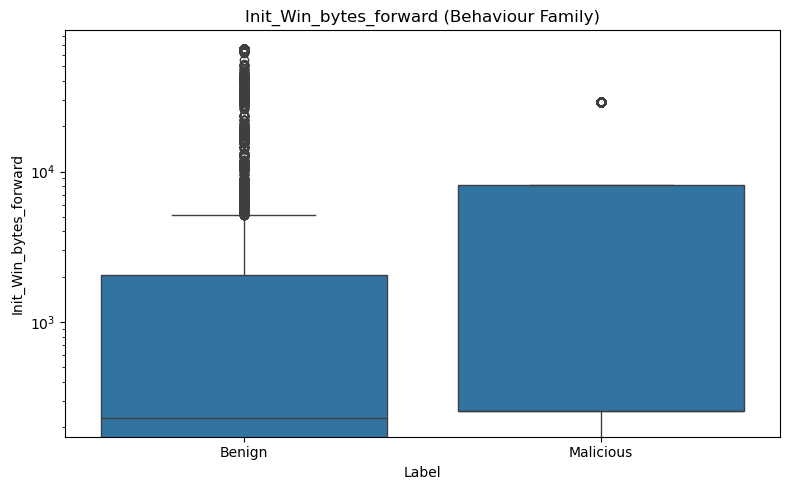

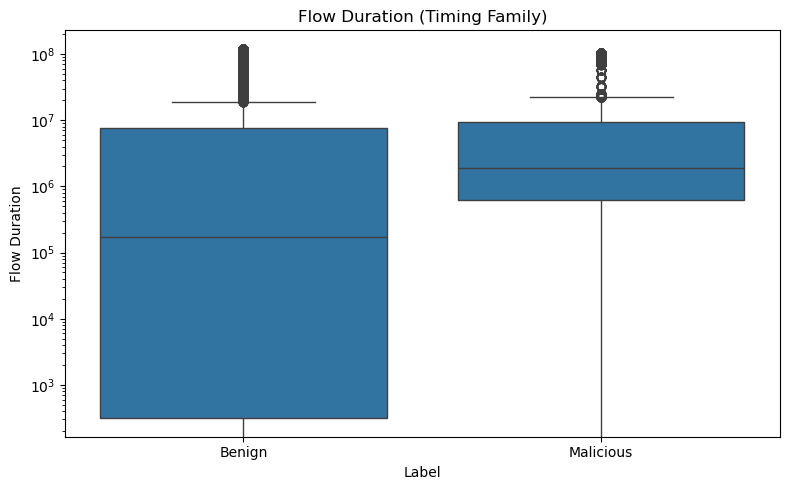

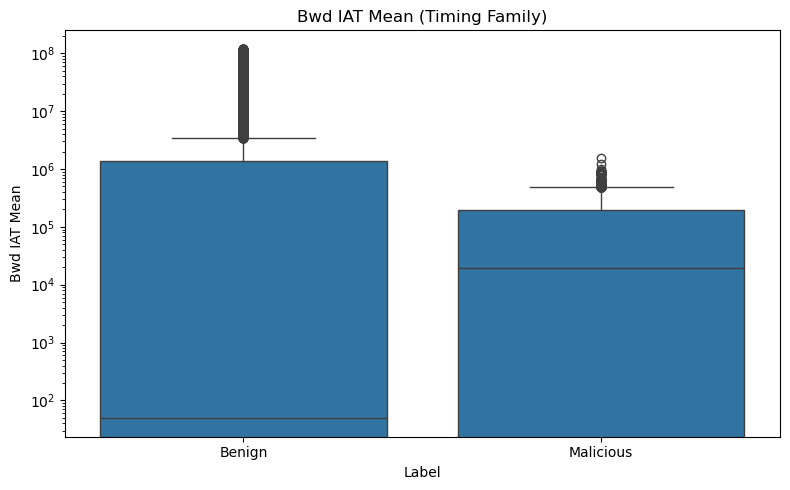

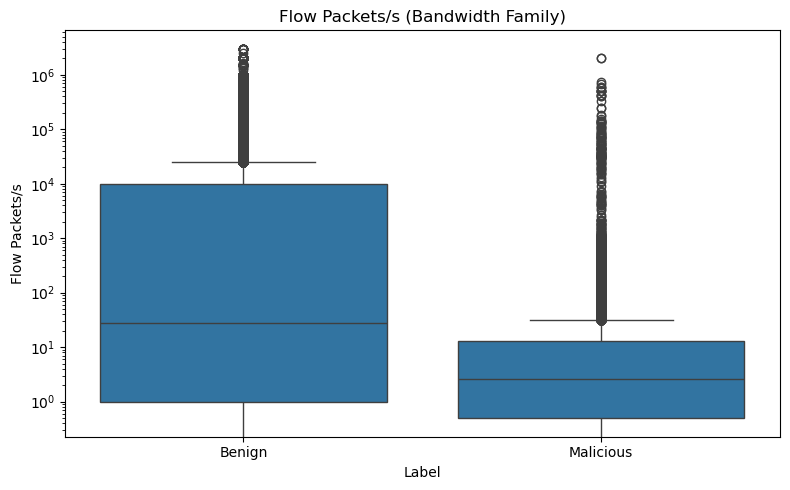

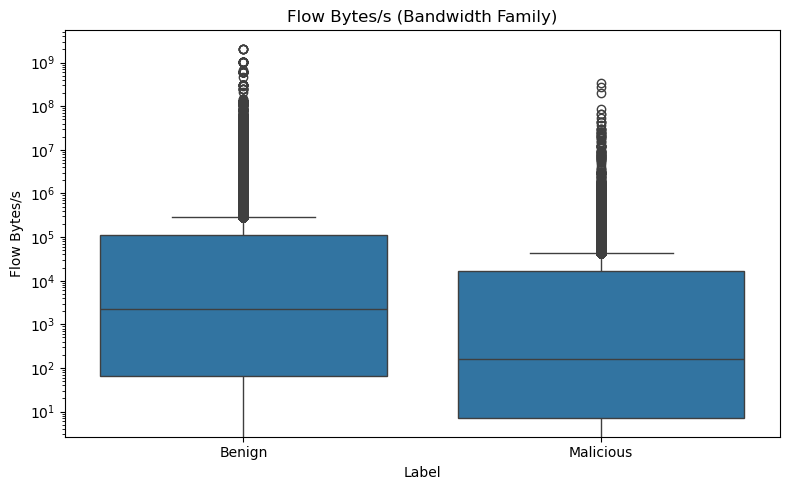

In [246]:
#Create box plots for each family of feature for distribution analysis

from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

x=df.drop(columns=["Label"])
#Get the benign and malicious samples
benignSamples=x[df["Label"]==0]
maliciousSamples=x[df["Label"]==1]

#Group the features by families of characteristics (e.g., timing based features)
fwdFamily=("Forward Family",["Total Length of Fwd Packets", "Fwd Packet Length Max", "Total Fwd Packets", "act_data_pkt_fwd"])
bckFamily=("Backward Family",["Bwd Packet Length Min", "Bwd Packet Length Max"])
behaviorFamily=("Behaviour Family",["Init_Win_bytes_forward"])
timingFamily=("Timing Family",["Flow Duration", "Bwd IAT Mean"])
bandwidthFamily=("Bandwidth Family",["Flow Packets/s", "Flow Bytes/s"])
allSamples=[fwdFamily,bckFamily,behaviorFamily,timingFamily,bandwidthFamily]

for plotTitle, featureNames in allSamples:
    for feature in featureNames:
        plt.figure(figsize=(8,5))

        sns.boxplot(x="Label", y=feature, data=df)

        plt.title(f"{feature} ({plotTitle})")
        #Plotting y and log scale so that values are spread out exponentially instead of linear (for better determining mal vs ben patterns)
        plt.yscale("log")
        plt.xticks([0,1], ["Benign","Malicious"])

        plt.tight_layout()
        plt.show()



### 1.5 ROC Plot Analysis
This analysis builds on the box plot analysis for determining how well individual features can distinguish between benign and malicious samples. Here, we're plotting every possible threshold value for distinguishing between samples. Every curve starts at 0, where a threshold is chosen so that everything is classified as a single category, then gradually decreased until everything is classified as the other class plotting the True Positive Rate (TPR) and False Positive Rate (FPR) along the way.

An Area Under the Curve (AUC) that is close to 0 or 1 is optimal for distinguishing between classes (0.5 is the worst value where it's no better than randomly guessing).

From the below, we can see that the top four features for distinguishing between the two classes (individually) are: 
- Bwd Packet Length Min: 0.20 AUC Score
- Fwd Packet Length Max: 0.25 AUC Score
- Init_Win_Bytes_forward: 0.75 AUC Score
- act_data_pkt_fwd: 0.74 AUC Score

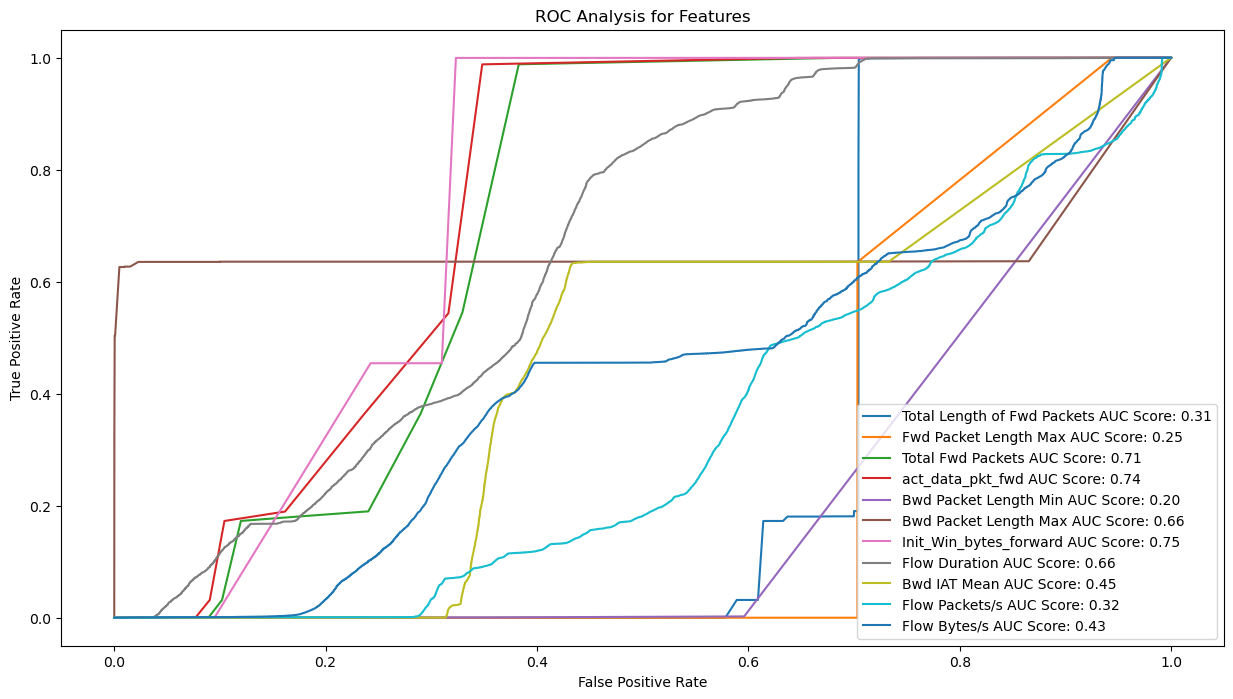

In [247]:
#Code to plot a ROC curve and record the area under the curve (AUC) using sklearns built-in functions

from sklearn.metrics import roc_curve, auc

def plotROCCurve(df):
    plt.figure(figsize=(15,8))
    #Just keeping same features of interest as box plot analysis
    featuresOfInterest=["Total Length of Fwd Packets", "Fwd Packet Length Max", "Total Fwd Packets", "act_data_pkt_fwd","Bwd Packet Length Min", "Bwd Packet Length Max","Init_Win_bytes_forward","Flow Duration", "Bwd IAT Mean", "Flow Packets/s", "Flow Bytes/s"]
    for feature in featuresOfInterest:
        #Compute false positive rate and true positive rate using built-in sklearn functions
        #Ref https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
        fpr,tpr,_=roc_curve(df["Label"],df[feature])
        aucScore=auc(fpr,tpr)
        plt.plot(fpr,tpr,label=f"{feature} AUC Score: {aucScore:.2f}")

    #Set all the labels and show the legend
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Analysis for Features")
    plt.legend()
    plt.show()

plotROCCurve(df)

### 1.6 Scatter Plot Analysis

The above Box plot and ROC curve analysis showed several features of interest for individual classification between benign and malicious samples. Here, we're creating scatter plots between features of interest, prioritizing features that have different characteristics (we're analyzing how pairs of features can help to distinguish between classes instead of individually)

##### Analysis of scatter plots

**Flow Duration as a Function of Fwd Packet Length Max**
This plot shows a clear separation between benign and malicious samples; however, only for the Fwd Packet Length Max portion - we can see that anything with Fwd Packet Length Max higher than ~220 is benign
Fwd Packet Length Max alone is a strong discriminator; Flow Duration does not significantly improve separability here.

**Bwd Packet Length Max as a function of Total Length of Fwd Packets**
This shows decent separation on the y and x axis. We can see that if Bwd Packet Length Max is between 10 and 1000 and Total Length of Pwd Packet is greater than 100, we can capture most traffic as benign. In otherwords, high forward traffic length coupled with normal backward traffic length is a good indication that the traffic is benign. 

**Init_Win_bytes_forward as a Function of Flow Packets/s**
We can see that with init_win_bytes_forward between 300 and ~5,000 we can classify most samples as benign  as with init_win_bytes_forward >~300 and Flow Packets/s > ~10,000. In otherwords, Init_win_bytes_forward exhibits strong clustering independent of FlowPacket/s

**Fwd Packet Length Max as a Function of act_data_pkt_fwd**
Exhibts great separation but only on a single axis. We can see that Fwd Packet Length Max higher than 20 will likely classify as benign

**Fwd Packet Length Max as a Function of Init_Win_bytes_forward**
Same as above - great separation, but only for Fwd Packet Length Max (only along one axis)

**Flow Packets/s as a Function of Flow Duration**
We can see that both the malicious and benign samples follow roughly the same shape. We can see that malicious are more tightly clustered, whereas there is more dispersion in benign. Not great for separating between the two due tothe overlap between the two classes.

**Bwd IAT Mean as a Function of Flow Duration**
We can see that if the Bwd IAT mean is less than ~200 we can classify most samples as benign (as well as if it's higher than 1,000,000). Again, only along one axis

**Total Length of Fwd Packets as a Function of Init_Win_bytes_forward**
Here, we can see that there is great separation along the individual axes, but their combination doesn't add anything useful.

**Fwd Packet Length Max as a Function of Flow Duration
Similar to the above, we can see that there is great separation along the Fwd Packet Length Max axis but not combined.

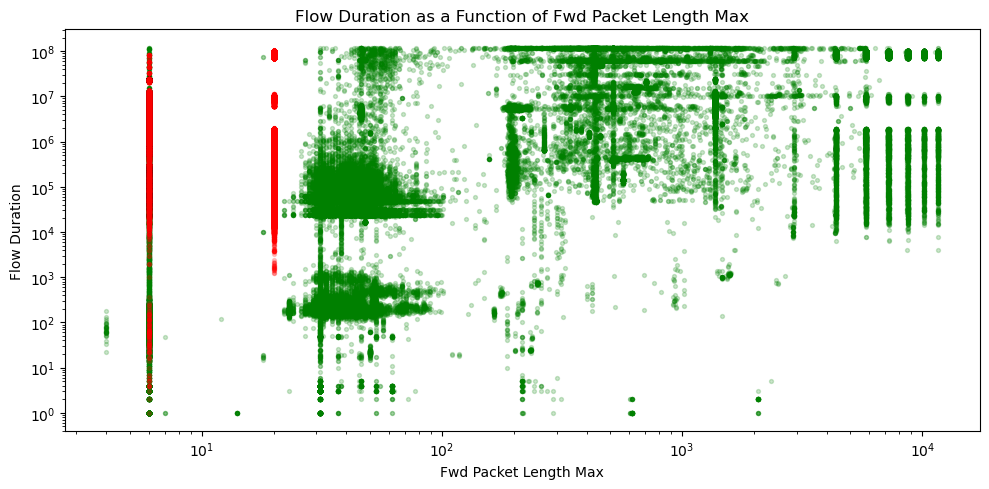

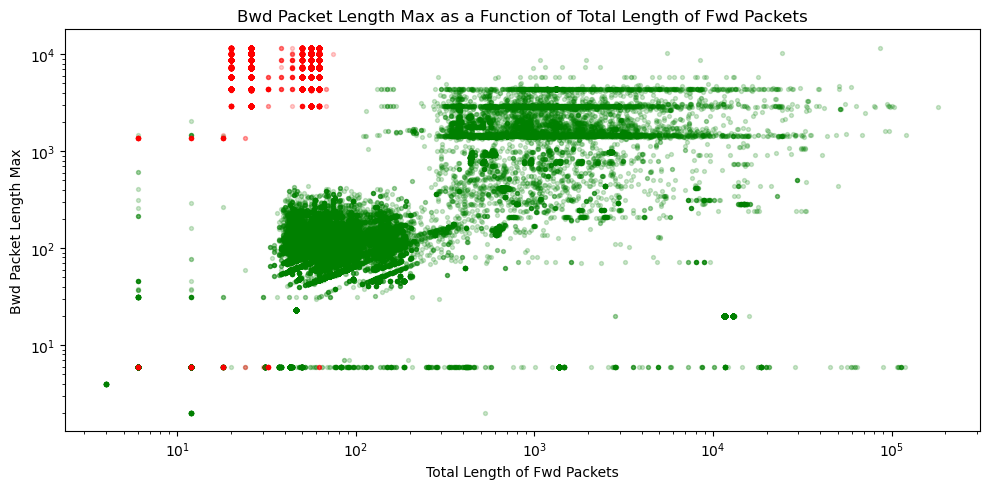

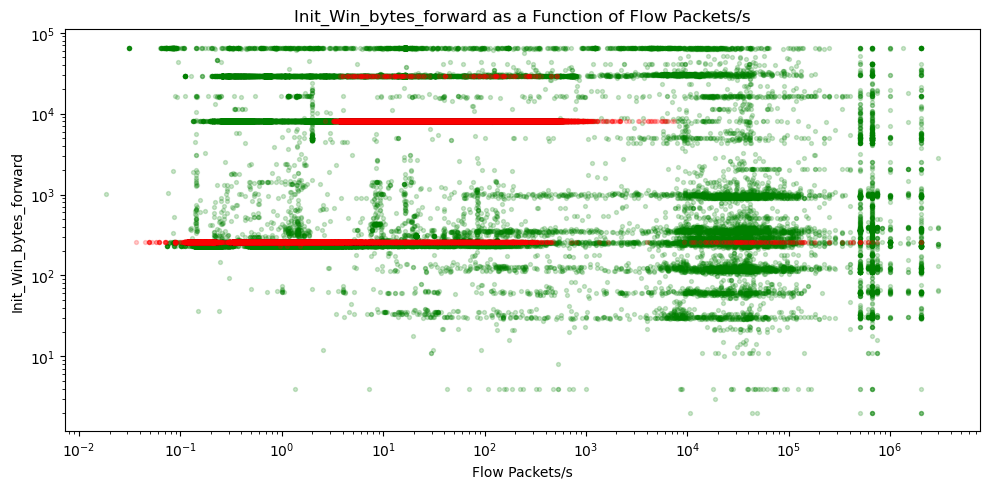

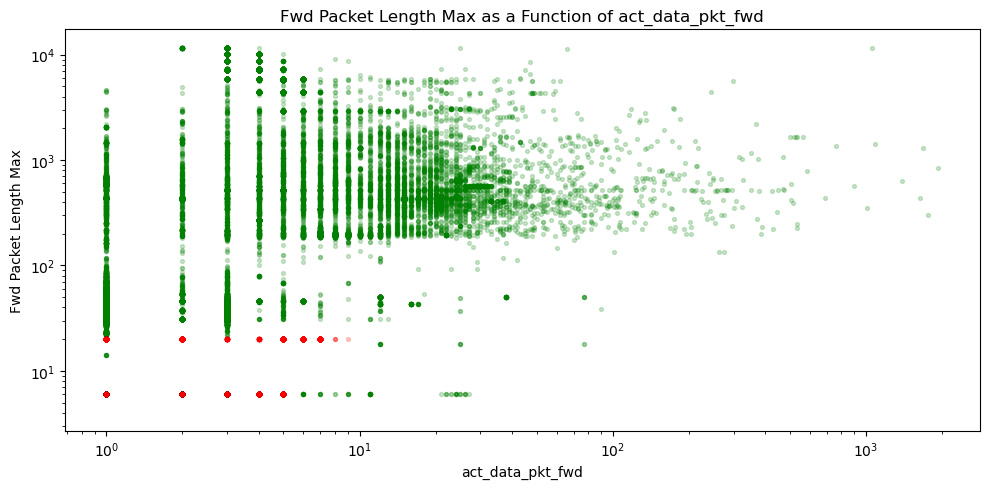

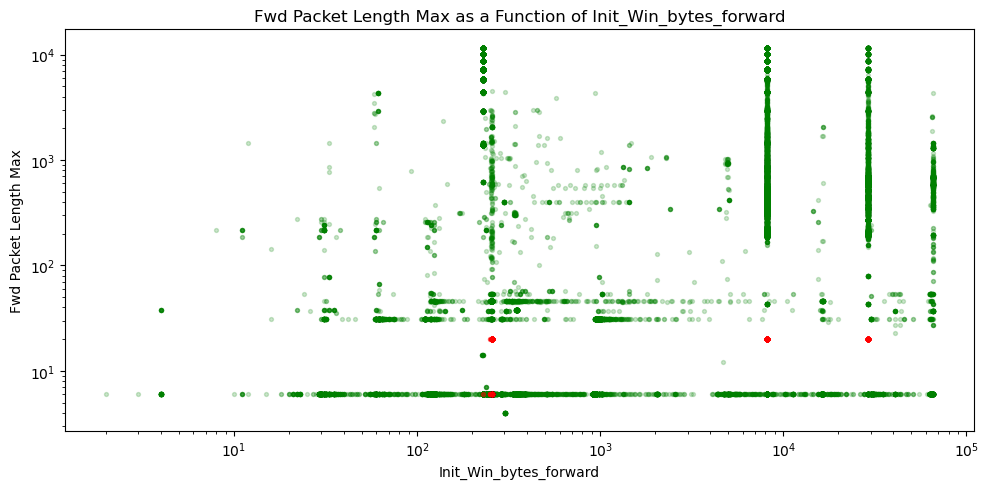

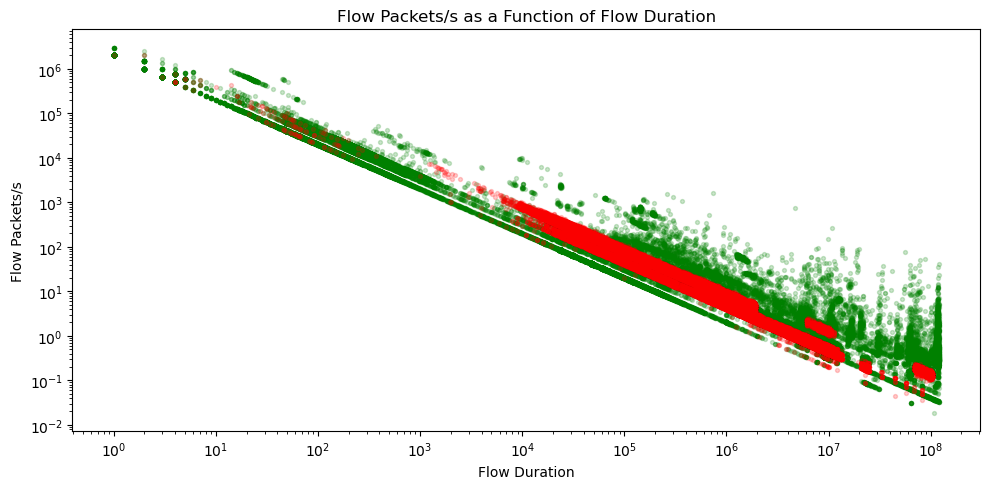

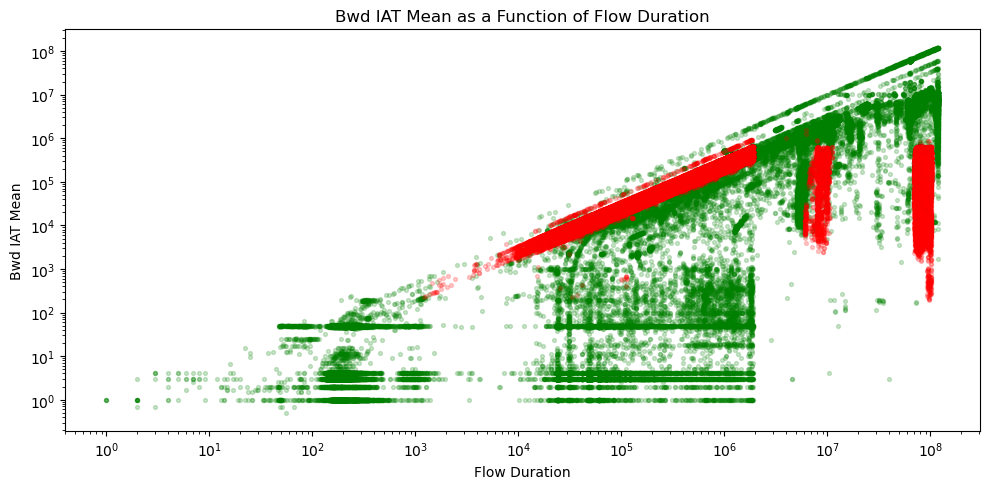

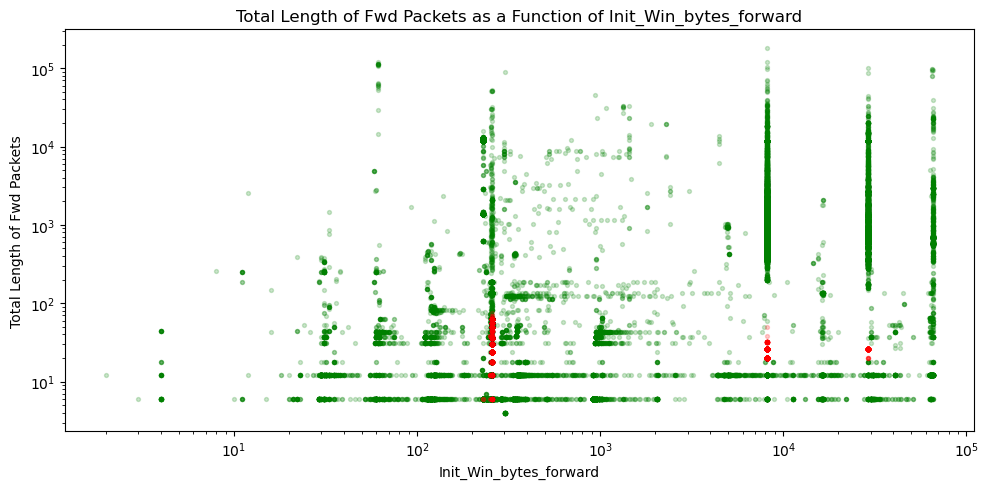

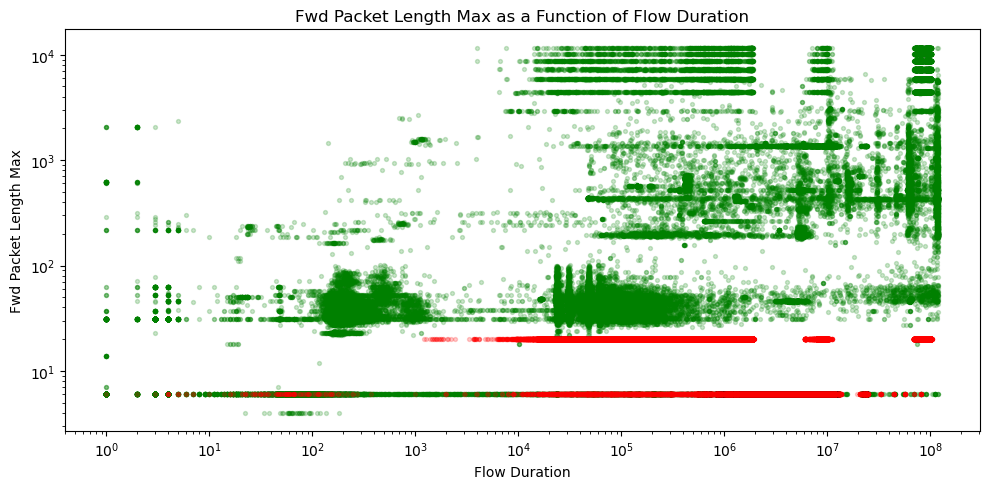

In [248]:
#Creating 9 scatter plots for the features of interest described above, prioritizing comparison of features with different behavioural characteristics

#Ref what learned from EE593 for Exploratory Data Analysis
def plot2DScatter(df,feature1,feature2):
    #Set initial figure size
    plt.figure(figsize=(10,5))
    #Set benign samples for feature 1 and 2 to green
    plt.scatter(df[df["Label"]==0][feature1], df[df["Label"]==0][feature2],alpha=0.2,label="Benign",color="green",s=8)
    #Set malicious samples for feature 1 and 2 to red
    plt.scatter(df[df["Label"]==1][feature1], df[df["Label"]==1][feature2],alpha=0.2,label="DDoS",color="red",s=8)
    #Add all the labels and show the plot
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    #Make the axes log scale due to differences in distributions
    plt.xscale("log")
    plt.yscale("log")
    plt.title(f"{feature2} as a Function of {feature1}")
    plt.tight_layout()
    plt.show()

#Plot Flow Duration as a Function of Forward Packet Length Max
plot2DScatter(df=df,feature1="Fwd Packet Length Max",feature2="Flow Duration")

#Plot Bwd Packet Length Max as a Function of Total Length of Fwd Packets (DDoS being assymetric should see difference)
plot2DScatter(df=df,feature1="Total Length of Fwd Packets",feature2="Bwd Packet Length Max")

#Plot Init_Win_bytes_forward as a function of Flow Packets/s
plot2DScatter(df=df,feature1="Flow Packets/s",feature2="Init_Win_bytes_forward")

#Plot Fwd Packet Length Max as a Function of act_data_pkt_fwd
plot2DScatter(df=df,feature1="act_data_pkt_fwd",feature2="Fwd Packet Length Max")

#Plot Fwd Packet Length Max as a function of Init_Win_bytes_forward
plot2DScatter(df=df,feature1="Init_Win_bytes_forward",feature2="Fwd Packet Length Max")

#Plot Flow Packets/s as a Function of Flow Duration (DDoS typically high rate under short duration - hoping will give separation)
plot2DScatter(df=df,feature1="Flow Duration",feature2="Flow Packets/s")

#Plotting packet rate vs interarival time (if DDoS has tight timings)
plot2DScatter(df=df,feature1="Flow Duration",feature2="Bwd IAT Mean")

#Behavior vs size (interesting)
plot2DScatter(df=df,feature1="Init_Win_bytes_forward",feature2="Total Length of Fwd Packets")

#Duration vs packet size
plot2DScatter(df=df,feature1="Flow Duration",feature2="Fwd Packet Length Max")



After the above analysis, we evaluate the following four features as the best for our fuzzy inference engine:
- Fwd Packet Length Max
- Bwd Packet Length Max
- act_data_pkt_fwd
- Init_Win_Bytes_Fwd

## 2. Fuzzy Inference Engine

From the above EDA, we identified four features as potentially beneficial for designing our fuzzy inference engine:
- Fwd Packet Length Max
- Bwd Packet Length Max
- act_data_pkt_fwd
- Init_Win_Bytes_Fwd

### 2.1 Defining Membership Functions

The definitions of these functions will be based on the box plot and scatter plot analysis from above. To keep our fuzzy engine simple, we will use basic membership functions with the following lingusitic meanings:
- LOW: Small values for a feature
- MED: Values that are not small nor large for a feature
- HIGH: Large values for a feature 

As per the guidance of the course, we will define the membership functions using triangular functions as they are effective, and simple to define. Upon closer inspection, we can see that the ranges of these values is **vastly** different with the HIGH range being ~2,800 times greater than low for Fwd Packet Length Max. Inspecting the above box and scatter plots, we can estimate membership functions as:

**Fwd Packet Length Max**
- LOW: (5,25,40)
- MED: (25,80,500)
- HIGH: (100,2000,100000)

**Bwd Packet Length Max**
- LOW: (5,20,100)
- MED: (50,400,1500)
- HIGH: (500,5000,10000)

**act_data_pkt_fwd**
- LOW: (1,2,5)
- MED: (2,10,50)
- HIGH: (10,100,1000)

**Init_Win_bytes_forward**
- LOW: (1,200,500)
- MED: (400,800,1500)
- HIGH: (1000,4000,10000)

Due to these high differences, we will attempt to log-transform the features to scale them to similar ranges.

After applying quick ROC curve analysis, we can see that log scaling them didn't detriment their ability to distinguish between classes. It should be noted that in theory we should have redone the entire EDA process; however, validating just AUC is sufficient for this project.

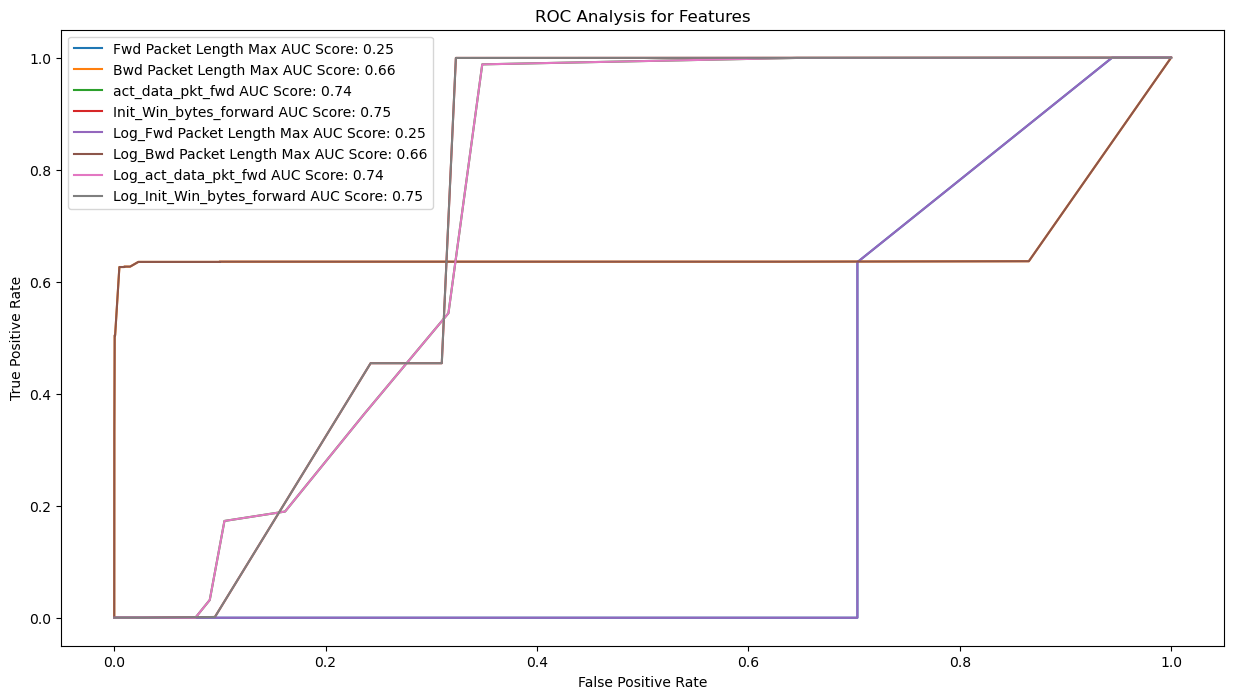

In [249]:
#Log scaling feature values and taking AUC curves to ensure that they're still consistent

def plotROCCurve(df):
    plt.figure(figsize=(15,8))
    #Just keeping same features of interest as box plot analysis
    featuresOfInterest=["Fwd Packet Length Max","Bwd Packet Length Max","act_data_pkt_fwd","Init_Win_bytes_forward","Log_Fwd Packet Length Max","Log_Bwd Packet Length Max",
                        "Log_act_data_pkt_fwd","Log_Init_Win_bytes_forward"]
    for feature in featuresOfInterest:
        #Compute false positive rate and true positive rate using built-in sklearn functions
        #Ref https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
        fpr,tpr,_=roc_curve(df["Label"],df[feature])
        aucScore=auc(fpr,tpr)
        plt.plot(fpr,tpr,label=f"{feature} AUC Score: {aucScore:.2f}")

    #Set all the labels and show the legend
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Analysis for Features")
    plt.legend()
    plt.show()

#Init_Win_bytes_forward uses -1 as placeholder - replace with 0 to make log valid
df["Init_Win_bytes_forward"] = df["Init_Win_bytes_forward"].clip(lower=0)

#Adding one to avoid invalid numbers (e.g)
df["Log_Fwd Packet Length Max"] = np.log10(df["Fwd Packet Length Max"] + 1)
df["Log_Bwd Packet Length Max"] = np.log10(df["Bwd Packet Length Max"] + 1)
df["Log_act_data_pkt_fwd"] = np.log10(df["act_data_pkt_fwd"] + 1)
df["Log_Init_Win_bytes_forward"] = np.log10(df["Init_Win_bytes_forward"] + 1)

plotROCCurve(df)

Now that have log scaled features of interest for our fuzzy inference engine, we will redo box plot analysis just for these four features. We can see that there are distinguishable characters across these distributions that match our previous analysis!

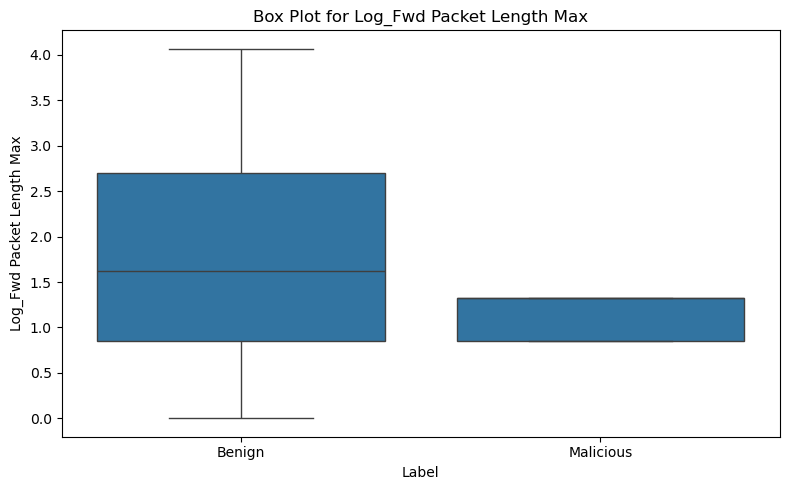

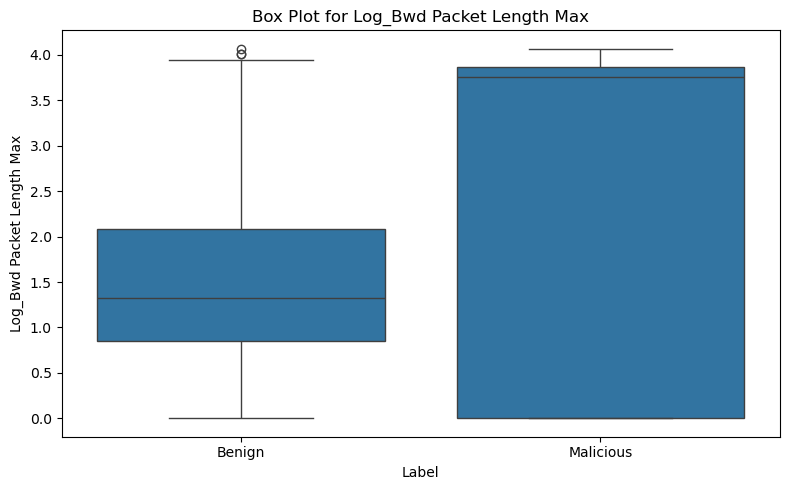

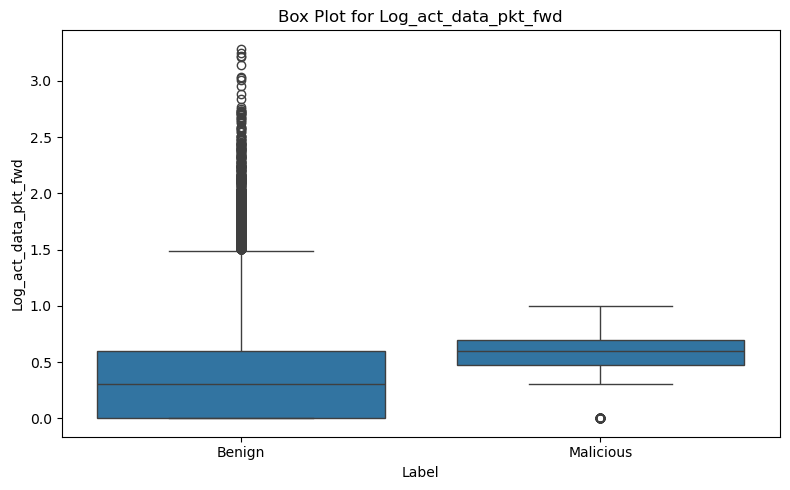

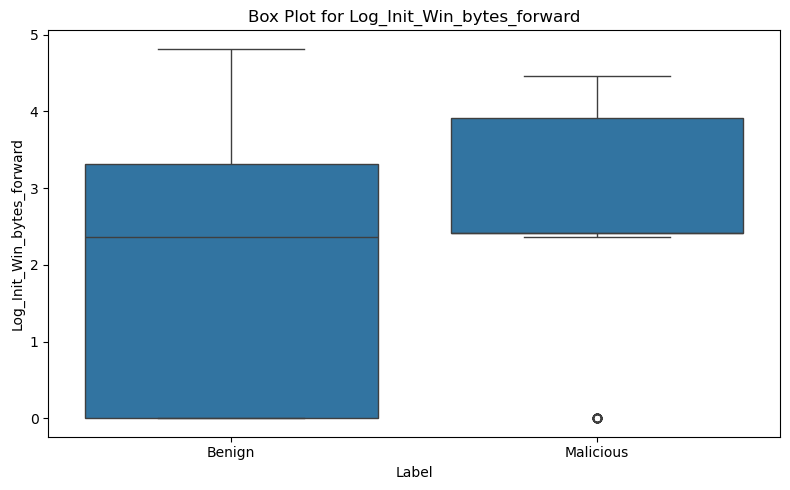

In [250]:
#Redoing box plot analysis now that we've log scaled the features of interest

x=df.drop(columns=["Label"])
#Get the benign and malicious samples
benignSamples=x[df["Label"]==0]
maliciousSamples=x[df["Label"]==1]

#Group the features by families of characteristics (e.g., timing based features)
featuresOfinterest=["Log_Fwd Packet Length Max","Log_Bwd Packet Length Max","Log_act_data_pkt_fwd","Log_Init_Win_bytes_forward"]

for feature in featuresOfinterest:
    plt.figure(figsize=(8,5))
    sns.boxplot(x="Label", y=feature, data=df)
    plt.title(f"Box Plot for {feature}")
    plt.xticks([0,1], ["Benign","Malicious"])

    plt.tight_layout()
    plt.show()

After having log scaled the features and recomputing the box plots, we can now created updated estimated triangular membership functions. To do this we're analyzing the box plots and making our best guess. Note that the classification behaviour of the membership function could be different (low could malicious for one feature but benign for another) - we'll capture this in our rulesets.

**Fwd Packet Length Max**

For this feature, low is more skewed to malicious and high is more skewed to benign
- LOW: (0.0,0.9,1.3) - Higher extent of malicious
- MED: (1,1.7,2.6) - Overlap between both
- HIGH: (1.7,3,4.5) - Higher extent of benign

**Bwd Packet Length Max**

For this feature low-medium is skewed to benign (0.6-2.1) and malicious has over 50% samples from 3.4-4 
- LOW: (0.0,1.3,1.9) - Higher extent of benign
- MED: (1.6,2.4,3.3) - Overlap 
- HIGH: (2.8,3.7,4.1) - Higher extent of malicious

**Act_data_pkt_fwd**

For this feature, 0-0.5 is mostly benign with big overlap between 0.5 and 0.6 and mostly malicious from 0.6-0.7
- LOW: (0.0,0.25,0.5) - Higher extent of benign
- MED: (0.4,0.5,0.8) - Overlap
- HIGH: (0.6,1.5,3.3) - Higher extent of malicious

**Init_Win_bytes_forward**

For this feature, 0-2.4 is mostly benign with overlap between 2.5 and 3.2 and then mostly malicious over 3.3
- LOW: (0,1.5,2.3) - Higher extent of benign
- MED: (2.1,3,3.5) - Overlap
- HIGH: (3.1,3.9,4.8) - Higher extent of malicious


For the output membership functions, we will start with using LOW, MED, and HIGH membership functions also for consistency (though not required). For simplicity, we'll just start using triangular functions that overlap on a universe of discourse of [0,1]

**IsMalicious**
- LOW: (0,0.25,05)
- MED: (0.25,0.5,0.75)
- HIGH: (0.5,0.75,1.0)


### Fuzzy Inference Rule Set
After analyzing the membership ranges for the features (and which lingusitic representation contains the most samples of one class), we developed the following rules:

**R1**: if Fwd Packet Length Max is LOW and Bwd Packet Length Max is HIGH then IsMalicious is HIGH      ELSE

**R2**: if Bwd Packet Length Max is HIGH and act_data_pkt_fwd is HIGH then IsMalicious is HIGH      ELSE

**R3**: if act_data_pkt_fwd is LOW and Init_Win_bytes_forward is HIGH then IsMalicious is HIGH     ELSE

**R4**: if Fwd Packet Length Max is LOW and Init_Win_bytes_forward is HIGH then IsMalicous is HIGH     ELSE

**R5**: if Fwd Packet Length Max is HIGH and Bwd Packet Length Max is LOW then IsMalicious is LOW     ELSE

**R6**: if Init_Win_bytes_forward is LOW and act_data_pkt_fwd is LOW then IsMalicious is LOW     ELSE

**R7**: if Bwd Packet Length Max is LOW and Init_Win_bytes_forward is LOW then IsMalicious is LOW     ELSE

**R8**: if Fwd Packet Length Max is MED and Bwd Packet Length Max is MED then IsMalicious is MED     ELSE

**R9**: if act_data_pkt_fwd is MED and Init_Win_bytes_forward is MED then IsMalicious is MED     ELSE

**R10**: if Fwd Packet Length Max is MED and Init_Win_bytes_forward is HIGH then IsMalicious is MED     ELSE

**R11**: if Fwd Packet Length Max is HIGH and act_data_pkt_fwd is HIGH then IsMalicious is MED     ELSE

**R12**: if Fwd Packet Length Max is LOW and Bwd Packet Length is LOW then IsMalicious is MED     ELSE

**R13**: if Bwd Packet Length is HIGH and Init_Win_bytes_forward is LOW then IsMalicious is MED

These rules were created by analyzing the ranges described above. Rules 1-4 cover samples that should have high degree of being malicious, rules 5-7 cover samples that have high degree of being benign, rules 8-10 cover samples that have high degree of being neither malicious or benign based on the distribution, and rules 11-13 are meant to deal with membership functions that provide conflicting information (by simply applying a degree of certainty as neither malicious or benign).



### 2.2 Creating the Fuzzy Inference Engine

Now that, we've defined the membership functions, their respective ranges, and the ruleset, we can move onto actually building the fuzzy inference engine! For this, we will follow the same mamdani min process that was explained in the course notes (lecture 10):

- Create the membership functions (as triangular functions) over each feature
- Convert the crisp feature values into degrees of membership
- Implement the above 13 rules using AND as min
  - Each rule will clip the output membership function (using mamdani min)
- Aggregate the results of the 13 rules using into a resulting fuzzy number (take max over all clipped output membership functions)
- Defuzzify the outputted fuzzy number (we'll just use Center of Areas (COA) for this)
- Convert the defuzzified number into a binary class (benign or malicious)


In [251]:
#Creating the actual fuzzy inference engine (most important code block in this project!). Mapping to the steps discussed above

###Define the membership functions
#x is the discrete value of the feature, and a,b,c are the left, peak, and right bounds of the triangle, respectively 
def computeMembershipDegree(x,a,b,c):
    #Return the degree which x belongs to the membership functiond efined by a,b,c. 
    #The first argument is the left (rising) edge and the second is the right (falling) edge
    #Then take minimum of the two slopes to get the membership degree for x
    #Ref ChatGPT for helping get it into such a compact form
    return np.maximum(
        np.minimum((x - a) / (b - a + 1e-9),
                   (c - x) / (c - b + 1e-9)),
        0
    )


###Define the universes of discourse of all membership functions 
#Global variables, but had to put under computeMembershipDegree function (since use function for their defintitions)
#Output universe (just making it 100 points between 0 and 1 to get to 2 decimals)
yUniverse=np.linspace(0,1,100)
#Output MFs
ddosLow=computeMembershipDegree(yUniverse,0,0.25,0.5)
ddosMed=computeMembershipDegree(yUniverse,0.25,0.5,0.75)
ddosHigh=computeMembershipDegree(yUniverse,0.5,0.75,1)

###Fuzzify the features
#Get degree sample belongs to each membership class for each feature
def fuzzify(sample):
    #Dictionary for storing all degrees of likelihood for each feature in sample
    sampleMembership={}
    fwd,bwd,act,init=sample
    
    #Fwd Packet Length Max membership values
    sampleMembership["fwdLow"]=computeMembershipDegree(fwd,0,0.9,1.3)
    sampleMembership["fwdMed"]=computeMembershipDegree(fwd,1,1.7,2.6)
    sampleMembership["fwdHigh"]=computeMembershipDegree(fwd,1.7,3.0,4.5)

    #Bwd Packet Length Max membership values
    sampleMembership["bwdLow"]=computeMembershipDegree(bwd,0,1.3,1.9)
    sampleMembership["bwdMed"]=computeMembershipDegree(bwd,1.6,2.4,3.3)
    sampleMembership["bwdHigh"]=computeMembershipDegree(bwd,2.8,3.7,4.1)

    #Act_data_pkt_fwd membership values
    sampleMembership["actLow"]=computeMembershipDegree(act,0,0.25,0.5)
    sampleMembership["actMed"]=computeMembershipDegree(act,0.4,0.5,0.8)
    sampleMembership["actHigh"]=computeMembershipDegree(act,0.6,1.5,3.3)

    #Init_Win_bytes_forward membershipvalues
    sampleMembership["initLow"]=computeMembershipDegree(init,0,1.5,2.3)
    sampleMembership["initMed"]=computeMembershipDegree(init,2.1,3,3.5)
    sampleMembership["initHigh"]=computeMembershipDegree(init,3.1,3.9,4.8)

    return sampleMembership


###Define and Evalute the Mamdani Ruleset
def evaluateMamdaniRules(membershipVals):
    outputMembership=[]
    ruleOutputs={}

    #HIGH rules
    ruleOutputs["R1"]=min(membershipVals["fwdLow"],membershipVals["bwdHigh"])
    ruleOutputs["R2"]=min(membershipVals["bwdHigh"],membershipVals["actHigh"])
    ruleOutputs["R3"]=min(membershipVals["actLow"],membershipVals["initHigh"])
    ruleOutputs["R4"]=min(membershipVals["fwdLow"],membershipVals["initHigh"])

    #Create the clipped output membership for the high rules
    for ruleNumber in range(1,5):
        outputMembership.append(np.minimum(ruleOutputs[f"R{ruleNumber}"],ddosHigh))

    #LOW rules
    ruleOutputs["R5"]=min(membershipVals["fwdHigh"],membershipVals["bwdLow"])
    ruleOutputs["R6"]=min(membershipVals["initLow"],membershipVals["actLow"])
    ruleOutputs["R7"]=min(membershipVals["bwdLow"],membershipVals["initLow"])

    #Create the clipped output membership for the low rules
    for ruleNumber in range(5,8):
        outputMembership.append(np.minimum(ruleOutputs[f"R{ruleNumber}"],ddosLow))

    #MED rules
    ruleOutputs["R8"]=min(membershipVals["fwdMed"],membershipVals["bwdMed"])
    ruleOutputs["R9"]=min(membershipVals["actMed"],membershipVals["initMed"])
    ruleOutputs["R10"]=min(membershipVals["fwdMed"],membershipVals["initHigh"])
    ruleOutputs["R11"]=min(membershipVals["fwdHigh"],membershipVals["actHigh"])
    ruleOutputs["R12"]=min(membershipVals["fwdLow"],membershipVals["bwdLow"])
    ruleOutputs["R13"]=min(membershipVals["bwdHigh"],membershipVals["initLow"])
    
    #Create the clipped output membership for the medium rules
    for ruleNumber in range(8,14):
        outputMembership.append(np.minimum(ruleOutputs[f"R{ruleNumber}"],ddosMed))

    #Combine all clipped memberships into single fuzzy set
    return np.maximum.reduce(outputMembership)

###Defuzzify the number back into crisp value
def defuzzify(fuzzySet):
    return np.sum(yUniverse*fuzzySet) / (np.sum(fuzzySet)+1e-9)

###Converting crisp output into classification
def convertToBinary(outputValue, threshold=0.5):
    #Malicious
    if outputValue > threshold:
        return 1
    #Benign
    else:
        return 0

###Function for stepping through functions to establish entire end-to-end pipeline
def runFuzzyPipeline(sample):
    membershipDegrees=fuzzify(sample)
    fuzzySet=evaluateMamdaniRules(membershipDegrees)
    crispOutput=defuzzify(fuzzySet)
    return convertToBinary(crispOutput)


Now that have defined our fuzzy inference engine, let's test its performance! We can see that the F1-score is 72.5%, not impressive. This will require further tuning.

In [252]:
#Function for computing performance metrics

from sklearn import metrics

#Just defining function for computing standard scores in one go
def computeScores(actualLabels, predictedLabels):
    confusionMatrix=metrics.confusion_matrix(actualLabels, predictedLabels)
    precision=metrics.precision_score(actualLabels, predictedLabels)
    recall=metrics.recall_score(actualLabels, predictedLabels)
    accuracy=metrics.accuracy_score(actualLabels, predictedLabels)
    f1=metrics.f1_score(actualLabels, predictedLabels)
    print("Confusion Matrix: \n", confusionMatrix)
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")

In [253]:
#Splitting testing and training set and then computing the performance of our engine!
#Note that using 12% size of training set due to long training

from sklearn.model_selection import train_test_split

#Was taking awhile to run, so only use 10% of the dataset (using stratify to ensure same proportion of class labels)
featuresOfinterest=["Log_Fwd Packet Length Max","Log_Bwd Packet Length Max","Log_act_data_pkt_fwd","Log_Init_Win_bytes_forward"]
X=df[featuresOfinterest].to_numpy()
Y=df["Label"].astype(int).to_numpy()
xTrain,xTest,yTrain,yTest=train_test_split(X,Y,test_size=0.1,random_state=20,stratify=Y)

#Take subset of training as well for more efficient tuning
xTrain,_,yTrain,_=train_test_split(xTrain,yTrain,train_size=0.12,random_state=20,stratify=yTrain)

predictions = np.array([runFuzzyPipeline(sample) for sample in xTest])

#Compute scores against labels and predictions!
computeScores(yTest,predictions)

Confusion Matrix: 
 [[8361 1411]
 [4713 8090]]
Accuracy: 0.7287264673311185
Precision: 0.8514893169140091
Recall: 0.6318831523861594
F1 Score: 0.7254304160688666


Now we'll check the output distribution of the crisp number to see the distribution between malicious and benign samples.
Here, we're plotting the count of samples as a function of their crisp output score. Overall, we can see that there is a ton of overlap between malicious and benign samples at output score higher than ~4.5 - meaning that our limitations don't stem simply from poor thresholding.

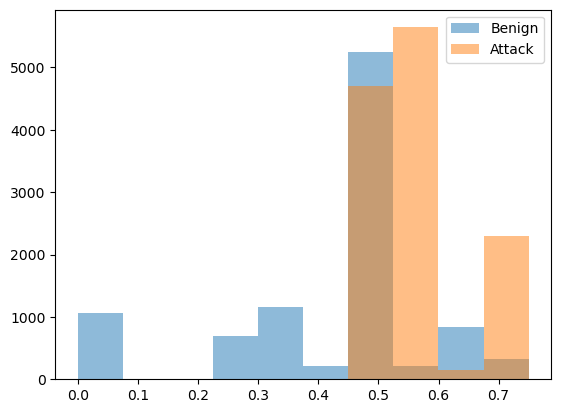

In [254]:
#Graphing the occurrence of malicious and benign samples as function of their output membership values

import matplotlib.pyplot as plt

def getCrispOutput(sample):
    membershipDegrees=fuzzify(sample)
    fuzzySet=evaluateMamdaniRules(membershipDegrees)
    crispOutput=defuzzify(fuzzySet)
    return crispOutput

outputs=[getCrispOutput(x) for x in xTest]

#Ref ChatGPT for help the below - just plotting the benign against malicious 
#Really just p
plt.hist([o for o,y in zip(outputs,yTest) if y==0], alpha=0.5, label="Benign")
plt.hist([o for o,y in zip(outputs,yTest) if y==1], alpha=0.5, label="Attack")
plt.legend()
plt.show()

### 2.3 Tuning the Fuzzy Inference Engine

From the above, we can see that performance is not optimal with an F1 score of 72.5%. We can see that we have 4713 False Negatives (incorrectly classifying DDoS as benign) and 1411 False Positives (incorrectly classifying benign as DDoS). This means our engine might be too strict towards benign.

Now we'll try some tuning! We will tune against the training set to not leak any of the data into our test set (to avoid "cheating")

From the above histogram, we can see that our thresholding isn't ideal (although this is not the biggest problem), we'll try different thresholds for differentiating between benign and DDoS. We arbitrarily chose 0.5 as the threshold (because it's the middle value of the output membership); however, this was chosen arbitrarily. Here we're just doing simple search over 20 threshold values between 0.3 and 0.6 and using the F1 score (since it's a balance between precision and recall) for quantifying the effectiveness of the threshold. We can see that 0.489 is the opitmal threshold value with an F1 score of 79.5% - a 7% increase from the above (assuming training set has similar properties to that of the test).

In [255]:
#Run through thresholds between 0.3 and 0.6 and keep track of which yield the highest F1 score

def thresholdTuning(lowRange=0.3,highRange=0.6,numIterations=20):
    #Adding extra argument to running our pipeline to enable us to select a threshold
    def runFuzzyPipelineWithThreshold(sample, threshold=0.5):
        membershipDegrees=fuzzify(sample)
        fuzzySet=evaluateMamdaniRules(membershipDegrees)
        crispOutput=defuzzify(fuzzySet)
        return convertToBinary(crispOutput,threshold=threshold)

    #Try thresholding with 20 values values between 0.3 and 0.7 (really could have focused on 0.4 to 0.5 in above histogram, but could be different since this is training set)
    thresholds = np.linspace(lowRange, highRange, numIterations)
    #Dictionary for holding F1 score for each threshold
    thresholdF1Scores={}
    for threshold in thresholds:
        predictions=np.array([runFuzzyPipelineWithThreshold(sample,threshold) for sample in xTrain])
        thresholdF1Scores[threshold]=metrics.f1_score(yTrain, predictions)

    #Iterate through the threshold scores and print top 10!
    top10F1Scores=sorted(thresholdF1Scores.items(),key=lambda x: x[1],reverse=True)[:10]
    for threshold, score in top10F1Scores:
        print(f"Threshold: {threshold:.3f},F1: {score:.3f}")

thresholdTuning()

Threshold: 0.489,F1: 0.795
Threshold: 0.474,F1: 0.794
Threshold: 0.458,F1: 0.794
Threshold: 0.442,F1: 0.794
Threshold: 0.426,F1: 0.794
Threshold: 0.411,F1: 0.792
Threshold: 0.395,F1: 0.792
Threshold: 0.379,F1: 0.792
Threshold: 0.363,F1: 0.786
Threshold: 0.347,F1: 0.780


The thresholding wasn't optimal as expected from the histogram, so we will explore other avenues to improve performance!

As discussed in the analysis, there is a lot of overlap between malicious and benign features. As such, We inspected the rules and the membership function ranges. We can see that for the act_data_pkt_fwd feature, the range of the HIGH membership function is much greater than that of LOW and MED. We made high extend to 3.3 to accomodate for outliers; however, this would increase the firing strength of malicious rules. As such, we'll change this to extend to the box plot's whisker (top bound not including outliers). So:
- act_data_pkt_fwd HIGH from (0.6,1.5,3.3) to (0.7,1.0,1.5).

We can see that we have 6 MED rules that could potentially introduce excess uncertainty into the fuzzy engine. For this, we opted to remove three of the MED rules to reduce overlap in the aggregated output and improve rule selectivity. We kept R8 to keep the relationship between forward and backward packets, R9 to keep the relationship between behavior and forward, and R11 to capture unexpected samples with high backward and forward lengths. As such, we removed:
- R10,R12,R13 

Currently, the output membership functions are symmetric. With central bias introduced from our chosen defuzzification algorithm (COA), MED dominates the final crisp output. As such, we will adjust these so to scale down MED's dominance. Furthermore, we can see that we defined the LOW and HIGH memberships for the DDoS outputs as triangles, but we can see a general trend where the maliciousness of a sample is proportional to the output membership score. As such, we adjusted the output's membership LOW and HIGH memberships to be shouldered triangles, where the degree of membership starts at 1 for attributing the membership value.
- LOW: (0,0.25,0.5) -> (0,0.2,0.45) -> (0,0.4)
- MED: (0.25,0.5,0.75) -> (0.4,0.5,0.65)
- HIGH: (0.5,0.75,1) -> (0.6,0.8,1.0) -> (0.6,0.8)

Furthermore, when deciding the membership function ranges for our features, we used primarily box plot analysis (although used a bit of scatter plot too). Due to the box plot analysis showing the ability for features to different between classes indepndently, we introduced three independent rules to capture these effects:
- if Bwd Packet Length Max is HIGH then DDoS is HIGH
- if act_data_pkt_fwd is HIGH then DDoS is HIGH
- if init_win_bytes_forward is LOW then DDoS is LOW

Additionally, we applied rule scaling factors to imit the influence of certain rules overwhelming the aggregated output:
- Singular rules were weighted to max values of 0.6
  - Also helps prevent overgeneralizatin to a singular feature
- Medium rules were weighted to values of 0.75


In [256]:
#Not efficient, but just recopying the above fuzzy engine implementation and updating with respective changes.

###Define the membership functions
#x is the discrete value of the feature, and a,b,c are the left, peak, and right bounds of the triangle, respectively 
def computeMembershipDegree(x,a,b,c):
    #Return the degree which x belongs to the membership functiond efined by a,b,c. 
    #The first argument is the left (rising) edge and the second is the right (falling) edge
    #Then take minimum of the two slopes to get the membership degree for x
    #Ref ChatGPT for helping get it into such a compact form
    return np.maximum(
        np.minimum((x - a) / (b - a + 1e-9),
                   (c - x) / (c - b + 1e-9)),
        0
    )

#Additional membership functions to have the output exhibit optimal classification behavior (left-shoulder and right-shoulder triangles)
#Ref ChatGPT for helping me get these 2 functions in such a compact form!
def leftShoulderMembershipDegree(x, a, b):
    return np.maximum(
        np.minimum(1, (b - x) / (b - a + 1e-9)),
        0
    )

def rightShoulderMembershipDegree(x, a, b):
    return np.maximum(
        np.minimum((x - a) / (b - a + 1e-9), 1),
        0
    )

###Define the universes of discourse of all membership functions 
#Global variables, but had to put under computeMembershipDegree function (since use function for their defintitions)
#Output universe (just making it 100 points between 0 and 1 to get to 2 decimals)
yUniverse=np.linspace(0,1,100)
#Output MFs
ddosLow=leftShoulderMembershipDegree(yUniverse,0.2,0.45)
ddosMed=computeMembershipDegree(yUniverse,0.4,0.5,0.65)
ddosHigh=rightShoulderMembershipDegree(yUniverse,0.6,0.8)

###Fuzzify the features
#Get degree sample belongs to each membership class for each feature
def fuzzify(sample):
    #Dictionary for storing all degrees of likelihood for each feature in sample
    sampleMembership={}
    fwd,bwd,act,init=sample
    
    #Fwd Packet Length Max membership values
    sampleMembership["fwdLow"]=computeMembershipDegree(fwd,0,0.9,1.3)
    sampleMembership["fwdMed"]=computeMembershipDegree(fwd,1,1.7,2.6)
    sampleMembership["fwdHigh"]=computeMembershipDegree(fwd,1.7,3.0,4.5)

    #Bwd Packet Length Max membership values
    sampleMembership["bwdLow"]=computeMembershipDegree(bwd,0,1.3,1.9)
    sampleMembership["bwdMed"]=computeMembershipDegree(bwd,1.6,2.4,3.3)
    sampleMembership["bwdHigh"]=computeMembershipDegree(bwd,2.8,3.7,4.1)

    #Act_data_pkt_fwd membership values
    sampleMembership["actLow"]=computeMembershipDegree(act,0,0.25,0.5)
    sampleMembership["actMed"]=computeMembershipDegree(act,0.4,0.5,0.8)
    sampleMembership["actHigh"]=computeMembershipDegree(act,0.7,1.0,1.5)

    #Init_Win_bytes_forward membershipvalues
    sampleMembership["initLow"]=computeMembershipDegree(init,0,1.5,2.3)
    sampleMembership["initMed"]=computeMembershipDegree(init,2.1,3,3.5)
    sampleMembership["initHigh"]=computeMembershipDegree(init,3.1,3.9,4.8)

    return sampleMembership

###Define and Evalute the Mamdani Ruleset
def evaluateMamdaniRules(membershipVals):
    outputMembership=[]
    ruleOutputs={}

    #HIGH rules
    ruleOutputs["R1"]=min(membershipVals["fwdLow"],membershipVals["bwdHigh"])
    ruleOutputs["R2"]=min(membershipVals["bwdHigh"],membershipVals["actHigh"])
    ruleOutputs["R3"]=min(membershipVals["actHigh"],membershipVals["initHigh"])
    ruleOutputs["R4"]=min(membershipVals["fwdLow"],membershipVals["initHigh"])
    #Noticed the single high rules appeared to be dominating
    ruleOutputs["R5"]=min(membershipVals["bwdHigh"],0.75)
    ruleOutputs["R6"]=min(membershipVals["actHigh"],0.75)

    #Create the clipped output membership for the high rules
    for ruleNumber in range(1,7):
        outputMembership.append(np.minimum(ruleOutputs[f"R{ruleNumber}"],ddosHigh))

    #LOW rules
    ruleOutputs["R7"]=min(membershipVals["fwdHigh"],membershipVals["bwdLow"])
    ruleOutputs["R8"]=min(membershipVals["initLow"],membershipVals["actLow"])
    ruleOutputs["R9"]=min(membershipVals["bwdLow"],membershipVals["initLow"])
    ruleOutputs["R10"]=membershipVals["initLow"]

    #Create the clipped output membership for the low rules
    for ruleNumber in range(7,11):
        outputMembership.append(np.minimum(ruleOutputs[f"R{ruleNumber}"],ddosLow))

    #MED rules
    ruleOutputs["R11"]=min(membershipVals["fwdMed"],membershipVals["bwdMed"],0.6)
    ruleOutputs["R12"]=min(membershipVals["actMed"],membershipVals["initMed"],0.6)
    ruleOutputs["R13"]=min(membershipVals["fwdHigh"],membershipVals["actHigh"],0.6)

    
    #Create the clipped output membership for the medium rules
    for ruleNumber in range(11,14):
        outputMembership.append(np.minimum(ruleOutputs[f"R{ruleNumber}"],ddosMed))

    #Combine all clipped memberships into single fuzzy set
    return np.maximum.reduce(outputMembership)

###Defuzzify the number back into crisp value
def defuzzify(fuzzySet):
    return np.sum(yUniverse*fuzzySet) / (np.sum(fuzzySet)+1e-9)

###Converting crisp output into classification
def convertToBinary(outputValue, threshold=0.5):
    #Malicious
    if outputValue > threshold:
        return 1
    #Benign
    else:
        return 0

###Function for stepping through functions to establish entire end-to-end pipeline
def runFuzzyPipeline(sample,threshold=0.5):
    membershipDegrees=fuzzify(sample)
    fuzzySet=evaluateMamdaniRules(membershipDegrees)
    crispOutput=defuzzify(fuzzySet)
    return convertToBinary(crispOutput,threshold=threshold)


Seeing if the above helped our problems by recreating the histogram!

We can see that the attack cass has shifted right making the overlapped region more narrow and structured. However, there is still a ton of overlap betwen 0.5, and 0.6.
Next step would be to do a grid search over possible values for the membership functions of each feature to get optimal ranges; however, due to resource and time constraints, we're leaving it here.

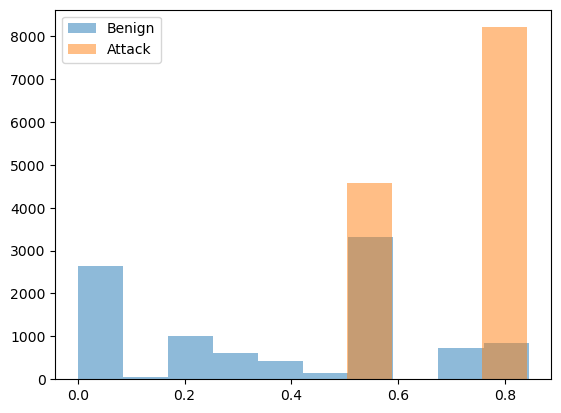

In [257]:
#Computing histogram showing the number of occurrences of benign and DDoS samples as a function of their respective membership scores

outputs=[getCrispOutput(x) for x in xTest]

#Ref ChatGPT for help the below - just plotting the benign against malicious 
#Really just p
plt.hist([o for o,y in zip(outputs,yTest) if y==0], alpha=0.5, label="Benign")
plt.hist([o for o,y in zip(outputs,yTest) if y==1], alpha=0.5, label="Attack")
plt.legend()
plt.show()

We then rewran threshold tuning, but made it centered around .45 to .8 (from the above histogram - where the benign and malicious overlap).

We can see that we're now able to get an F1 score of 0.909 using a threshold of 0.521 on the training dataset

In [258]:
#Repeat the threshold tuning using the updated fuzzy inference engine

thresholdTuning(0.45,0.8,100)

Threshold: 0.521,F1: 0.909
Threshold: 0.517,F1: 0.839
Threshold: 0.510,F1: 0.838
Threshold: 0.514,F1: 0.838
Threshold: 0.507,F1: 0.838
Threshold: 0.503,F1: 0.838
Threshold: 0.499,F1: 0.838
Threshold: 0.489,F1: 0.837
Threshold: 0.492,F1: 0.837
Threshold: 0.496,F1: 0.837


Now we perform the final evaluation (on the test set) with the updated inference engine and optimal threshold value.

We can see that the F1 score is high as expected at 91.19%; however, this number is inflated by a very strong recall score and moderately strong precision score. This means that our fuzzy engine is capturing almost every attack (only 13 False negatives), but has 2,458 false positives vs 7,314 true positives meaning that it falsly identifies benign samples as malicious ~25% of the time. It coud be argued this is good from a security perspective because almost no attack is being missed; however, the number of false positives here would bog down any operationally SOC making this engine not practical in industry.

Furthermore, it should be noted that the threshold value difference between .521 and .52070707 resulted in a ~18% difference in F1 score. This implies that the decision boundary of our fuzzy logic inference engine is quite fragile and not robust.

More hyperparameter tuning should be completed to get a cleaner separation between malicious and benign samples before anyone could even consider this engine ready operational use cases.

In [259]:
#Evaluate performance of updated inference engine with the optimal threshold value

predictions = np.array([runFuzzyPipeline(sample,threshold=0.5207070707) for sample in xTest])
#Compute scores against labels and predictions!
computeScores(yTest,predictions)

Confusion Matrix: 
 [[ 7313  2459]
 [   13 12790]]
Accuracy: 0.890498338870432
Precision: 0.838743524165519
Recall: 0.9989846129813325
F1 Score: 0.911877940966776


## 3. Neural models

Now that we have implemented and tested a fuzzy logic inference engine, we will compare performance against neural models.

To keep the assessment fair, we will limit the neural models to the same four engineered features we used to build our fuzzy inference engine.

### 3.1 Perceptron

Starting off with the single Perceptron from Lecture 12 which learns a linear boundary for separating the samples.

We can see that using a simple perceptron model already surpasses the performance of our fuzzy inference engine with an F1-score of 96.2%. This hurts the self-esteem considering that this took less than a percent of the time as the fuzzy inference engine, but very cool from a learning perspective!

In [260]:
#Evaluating SKLearn's built-in Perceptron model - we can see that using all default values surpasses our engine!

from sklearn.linear_model import Perceptron

perceptronModel=Perceptron()

#Redefine to be safe
featuresOfinterest=["Log_Fwd Packet Length Max","Log_Bwd Packet Length Max","Log_act_data_pkt_fwd","Log_Init_Win_bytes_forward"]
X=df[featuresOfinterest].to_numpy()
Y=df["Label"].astype(int).to_numpy()
xTrain,xTest,yTrain,yTest=train_test_split(X,Y,test_size=0.1,random_state=20,stratify=Y)

#Take subset of training as well for more efficient tuning
xTrain,_,yTrain,_=train_test_split(xTrain,yTrain,train_size=0.12,random_state=20,stratify=yTrain)

perceptronModel.fit(xTrain,yTrain)

predictions=perceptronModel.predict(xTest)

computeScores(yTest,predictions)

Confusion Matrix: 
 [[ 8796   976]
 [   23 12780]]
Accuracy: 0.9557475083056478
Precision: 0.9290491421924978
Recall: 0.9982035460438959
F1 Score: 0.9623856319891562


### 3.2 ADALINE 

Next we're moving to an Adaline network (Widrow-Hoff Learning) from Lecture 19

Can't find a good sklearn library for this, so just going to make it from scratch (single neuron Aldaline), following the guidance from lecture 19.

Overall, we can see that this network performed worse than the single node perceptron and the fuzzy inference engine. This is logical given the nature of the dataset and the objectives of each model.

The perceptron directly optimizes for classification correctness by updating only when misclassification occurs, effectively learning a linear decision boundary that separates benign classes from malicious ones. On the otherhand, Adaline, minimizes error, treating the problem as regression (continuous numbers) instead of classification and tries to fit to continuous values instead of just classification accuracy, boosting fluctuation.

As a result, Adaline is more sensitive to error magnitude which can result in suboptimal decision boundaries for classifications problems like this. We can see in the below, that error is decreased throughout training; however, this is towards the continuous values and the classes themselves. Overall, Adaline is not an optimal model choice for this problem.

In [261]:
#Custom implementation of Adaline network based on the steps from Lecture 19

class Adaline:
    def __init__(self,lr,epochs):
        self.lr=lr 
        self.epochs=epochs
        #Just like from notes start with 0 weight and 0 biase
        self.w=None
        self.b=None


    def fit(self,X,y):
        #Get number of features and samples for training
        numSamples,numFeatures=X.shape

        #Set weight vector to all zeroes initially
        self.w=np.zeros(numFeatures)
        self.b=0.0

        #Iterate through the number of epochs and apply formulas taught from lecture
        for epoch in range(self.epochs):
            #For each sample
            totalError=0
            for i in range(numSamples):
                #Keep sample and target
                xi=X[i]
                target=y[i]

                #Get the prediction (using purelin)
                pred=np.dot(self.w,xi) + self.b

                #Compute the error
                error=target-pred

                #Perform the LMS update to get new bias and new weights
                self.w = self.w+2*self.lr*error*xi
                self.b = self.b+2*self.lr*error
                
                totalError+=error
            if epoch % 10==0:
                print(f"Average error for epoch {epoch}: {totalError/numSamples}")
    def predict(self, X):
        #Just doing forward pass formula
        pred=np.dot(X,self.w)+self.b
        #Converting output into binary class (just saying if bigger than or equal to 1 malicious else benign)
        return (pred>=0).astype(int)

#Instantiate Adaline model using custom class defined above, train it on train set, and evaluate on the test set!
adalineModel=Adaline(lr=0.0001,epochs=100)
adalineModel.fit(xTrain,yTrain)
predictions=adalineModel.predict(xTest)
computeScores(yTest,predictions)

Average error for epoch 0: 0.039866921214154125
Average error for epoch 10: -0.00030867176598892344
Average error for epoch 20: -1.4053856839733345e-05
Average error for epoch 30: -4.816414101119523e-07
Average error for epoch 40: -1.625294358699974e-08
Average error for epoch 50: -5.479146113370344e-10
Average error for epoch 60: -1.846976130054279e-11
Average error for epoch 70: -6.223607833627871e-13
Average error for epoch 80: -2.0673431975521383e-14
Average error for epoch 90: -1.926405439323954e-16
Confusion Matrix: 
 [[ 2672  7100]
 [    0 12803]]
Accuracy: 0.6854928017718716
Precision: 0.643269858815254
Recall: 1.0
F1 Score: 0.7829144499480217


### 3.3 Multi-Layer Perceptron (MLP)


Switching over to Multi-Layer Perceptron (Feed Forward Neural Network). We saw that a single perceptron outperformed our fuzzy inference engine across all performance metrics. Now, we'll do the modern practice of sequentially stacking perceptrons to make a feed forward neural network and back propagate the loss to update each neuron as if it was a single system.

For the feed forward neural network we followed best practices for binary classification (ref: https://machinelearningmastery.com/building-a-binary-classification-model-in-pytorch/):
- Binary Cross entropy for the loss
- Decreasing number of neurons in the feed forward structure (used 32->16->8)
- Training against raw logits as outputs
- Using the adam optimizer
- Tracking the validation loss and breaking early if a plateau is detected

It should be noted that this project is focused on the fuzzy inference engine. There is a lot more that could have been done to optimize this MLP such as incorpating a decaying learning rate, hyperparameter tuning (e.g., grid search), and incorporating different architectures.

Overall, we can see that the MLP has the best performance yet, reaching an F1 score of 99.91%.

In [262]:
#Based this off some of the work done in EE593
#Implementng custom MLP, training it on same 4 features described above and evaluating it using the same performance metrics

import torch

import torch
import numpy as np

class MLP(torch.nn.Module):
    def __init__(self, inputSize, lr, hiddenDims=[32,16,8]):
        super().__init__()

        self.network = torch.nn.Sequential(
            torch.nn.Linear(inputSize, hiddenDims[0]),
            torch.nn.ReLU(),
            torch.nn.Linear(hiddenDims[0], hiddenDims[1]),
            torch.nn.ReLU(),
            torch.nn.Linear(hiddenDims[1], hiddenDims[2]),
            torch.nn.ReLU(),
            torch.nn.Linear(hiddenDims[2], 1)
        )
        
        #Binary cross entropy loss since we're doing binary classification
        self.lossFunc=torch.nn.BCEWithLogitsLoss()
        #Using adam optimizer because that's what otherse use (ref https://buqeye.github.io/LearningFromData/notebooks/Machine_learning/Neural_Network_for_simple_function_in_PyTorch.html)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=lr)
        #Was having GPU problems, so just using CPU
        self.device = torch.device('cpu')
        self.to(self.device)

    #Forward pass for the network - just pass sample sequentially through the layers
    def forward(self, sample):
        return self.network(sample)

    #Train the model
    def fit(self, XTrain, YTrain, XTest, YTest, epochs=100):
        
        #Convert to tensors
        XTrainTensor = torch.tensor(XTrain, dtype=torch.float32).to(self.device)
        YTrainTensor = torch.tensor(YTrain, dtype=torch.float32).unsqueeze(1).to(self.device)
        XTestTensor = torch.tensor(XTest, dtype=torch.float32).to(self.device)
        YTestTensor = torch.tensor(YTest, dtype=torch.float32).unsqueeze(1).to(self.device)

        #Found that training sometimes overshot - just keeping track of if loss doesn't decrease for x number of iterations, just quit (at min already!)
        lowestLoss=float("inf")
        #Saving model state so can get one corresponding to lowest loss
        bestModelState=None
        trainingMinHits=0
        

        for epoch in range(0,epochs):
            #Set model to training mode
            self.train()

            #clear gradients (accumulate by default leading to potential explosion)
            self.optimizer.zero_grad()

            #Compute the loss from the model's prediction
            predictions=self.forward(XTrainTensor)
            loss=self.lossFunc(predictions,YTrainTensor)

            #Back propagate against the computed loss and step one learning rate towards opposite direction of gradient (gradient descent)
            loss.backward()
            self.optimizer.step()

            #Track testing loss at each epoch (to make sure performance increasing and not overfitting)
            validationPreds=self.forward(XTestTensor)
            validationLoss=self.lossFunc(validationPreds,YTestTensor).item()
            
            if validationLoss<lowestLoss:
                lowestLoss=validationLoss
                bestModelState=self.network.state_dict()
                trainingMinHits=0
            else:
                trainingMinHits+=1


            #Print validation loss every 50 epochs
            if epoch%50==0:
                print(f"Loss at epoch {epoch}: {validationLoss}")

            #If training hasn't decreased validation loss 20 times in a row, then break!
            if trainingMinHits>19:
                print(f"Early stop triggered at epoch {epoch}")
                break

    #Get the prediction from the samples
    def predict(self,samples):
        #Convert samples to tensor:
        samples=torch.tensor(samples, dtype=torch.float32).to(self.device)
        #Get the raw logits
        logits=self.forward(samples)
        #Convert the logits into probably distirbution using sigmoid
        probs=torch.sigmoid(logits)
        #Convert predictions into classifications (using 0.5 as threshold)
        predictions=(probs>0.5).cpu().numpy().astype(int).flatten()
        return predictions

In [263]:
#Instantiate MLP model using custom class defined above, train it on train set, and evaluate on the test set!

mlp=MLP(inputSize=xTrain.shape[1],lr=0.005)
mlp.fit(xTrain,yTrain,xTest,yTest,epochs=1000)
predictions=mlp.predict(xTest)
computeScores(yTest,predictions)

RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
